# SQL _(1h30)_

> 1. **Modèle de données:** Le schéma de la base de données ci-dessous représente plusieurs tables.
Il existe des relations entre ces tables. Etablissez les relations entre ses tables, en signifiant à chaque fois quelle est la clé primaire, la clé étrangère.

![Schéma de la base de données](https://i.ibb.co/JFncBS2z/Livres-BDD.png)

Exemple:

`Table1` --- `Table2`. Clé primaire: `Table2[nom_champ]` Clé étrangère: `Table1[nom_champ]`

Ce modéle est un modèle du type OLTP en schéma normalisé, c'est à dire que les données sont séparés par entités métiers distinctes: 'Livre', 'Auteur', 'Genre' et une table de laison 'LivreGenre'. Nous pouvons ainsi relier les tables de métier entre elles grâce à la cardinalité des relations selon les paramètres suivants:
-`Auteur` --- `Livre`. Cardinalité: 1-N ; Clé primaire: `Auteur'[AuteurID]; `Clé étrangère: `Livre'[AuteurID],

-`LivreGenre` ---`Livre`. Cardinalité: 1-N ; Clé primaire: ``Livre'[LivreID] Clé étrangère: LivreGenre[LivreID],

- `Genre`--- `LivreGenre`. Cardinalité: 1-N ; Clé primaire: `Genre'[GenreID] Clé étrangère: `LivreGenre'[GenreID],

-Relation métier principale : 'Livre' --- 'Genre'

- **Cardinalité :** N-N  
- **Implémentation :** via la table `LivreGenre`  




> 2. Toujours en se basant sur le schéma de la base de données, existe-t-il une table intermédiare ? Si oui, quel est le nom de cette table ? Dans quelle situation il est recommandé de créer une table intermédiare pour connecter deux tables ?

La table `LivreGenre` contient :
- `LivreGenre[LivreID]`
- `LivreGenre[GenreID]`

Elle permet de résoudre la relation plusieurs-à-plusieurs entre `Livre` et `Genre`.

La clé primaire idéale est ce que l'on appelle une **clé composite** :
- `LivreGenre[LivreID, GenreID]`

Créer une tavle intermédiaire garantit l’unicité des associations (un livre ne peut pas être lié deux fois au même genre).



Réponse:


3. Requêtes SQL

Exécuter la cellule de code ci-dessous pour se connecter à la base de données.

In [7]:
import os
import requests
import zipfile
import sqlite3

# Je m'assure que le dossier data/ existe
os.makedirs('../data', exist_ok=True)

# Je télécharge le zip dans data/
url = "https://github.com/MaskiVal/Html/raw/main/biblio_F.sqlite3.zip"
r = requests.get(url)
open('../data/biblio_F.sqlite3.zip', 'wb').write(r.content)

# Je dézippe dans data/
with zipfile.ZipFile("../data/biblio_F.sqlite3.zip", "r") as zip_ref:
    zip_ref.extractall('../data/')

# Je me connecte à la base
conn = sqlite3.connect('../data/biblio_F.sqlite3')


Voici une représentation des valeurs de votre base de données :

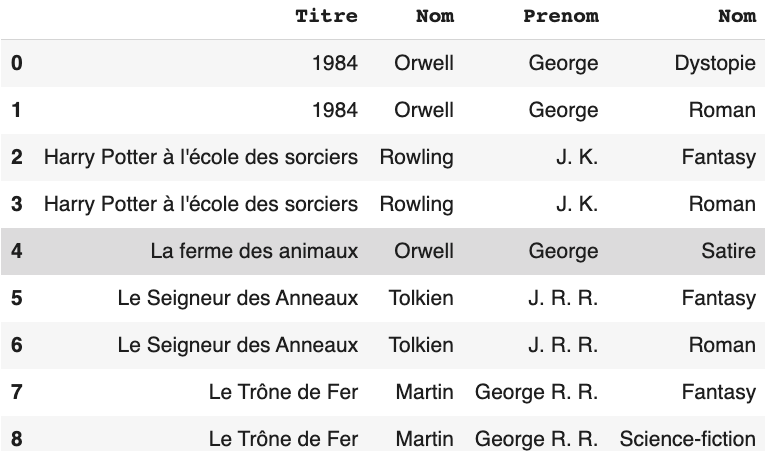

In [8]:
# Voici un exemple de requête sql. La requête SQL est entre guillemets pour le premier argument, puis la variable conn en second argument.

pd.read_sql("""SELECT * FROM Auteur""", conn)

NameError: name 'pd' is not defined

Effectuer des requêtes, pour répondre aux questions suivantes.

> 3.1 Renvoyer le nom du genre qui contient le plus de livres, ainsi que le nombre de livres pour ce genre.

In [ ]:
pd.read_sql("""
SELECT
    Genre.Nom AS nom_genre,  -- Je sélectionne le nom du genre pour l'affichage
    COUNT(LivreGenre.LivreID) AS nombre_livres  -- Je compte le nombre de livres associés à chaque genre

FROM Genre

--Je relie la table Genre à la table de liaison pour accéder aux associations livre-genre
JOIN LivreGenre
    ON Genre.GenreID = LivreGenre.GenreID

-- Je regroupe par genre pour calculer le nombre de livres par catégorie
GROUP BY Genre.GenreID, Genre.Nom

-- Je filtre uniquement les genres ayant le nombre maximal de livres
HAVING COUNT(LivreGenre.LivreID) = (

    -- Sous-requête : je calcule le nombre de livres par genre
    SELECT MAX(nb_livres)
    FROM (
        SELECT COUNT(LivreGenre.LivreID) AS nb_livres
        FROM LivreGenre
        GROUP BY LivreGenre.GenreID
    ) AS nombre_de_livre_par_genre
);
""", conn)

,nom_genre,nombre_livres
0,Fantasy,3
1,Roman,3


Résultat attendu:  
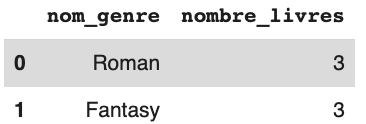

> 3.2 Renvoyer le nombre de livres et d'auteurs par genre, dans l'ordre décroissant par rapport au nombre de livres.


In [ ]:
pd.read_sql("""
SELECT
    Genre.GenreID,
    Genre.Nom,

    -- Je compte le nombre de livres distincts par genre
    COUNT(DISTINCT LivreGenre.LivreID) AS nb_livre,

    -- Je compte le nombre d’auteurs distincts associés à ces livres
    COUNT(DISTINCT Livre.AuteurID) AS nb_auteur

FROM Genre

-- Liaison genre → livres
JOIN LivreGenre
    ON Genre.GenreID = LivreGenre.GenreID

-- Liaison livres → auteurs
JOIN Livre
    ON LivreGenre.LivreID = Livre.LivreID

-- Agrégation par genre
GROUP BY Genre.GenreID, Genre.Nom

-- Tri décroissant sur le nombre de livres
ORDER BY nb_livre DESC;
""", conn) #Plus lisible comme cela que dans le résultat attendu

,GenreID,Nom,nb_livre,nb_auteur
0,1,Fantasy,3,3
1,3,Roman,3,3
2,2,Science-fiction,1,1
3,4,Dystopie,1,1
4,5,Satire,1,1


Résultat attendu:
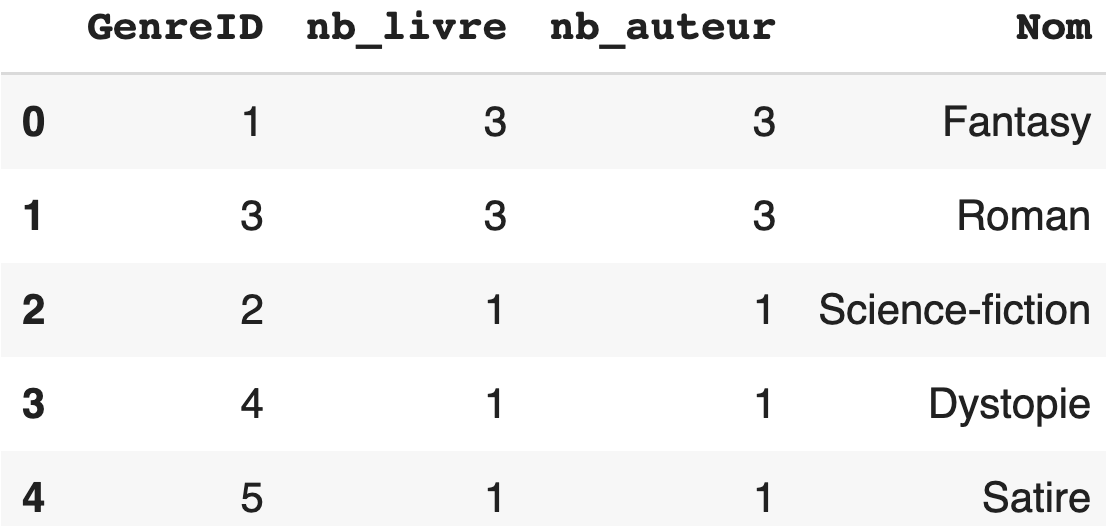

> 3.3 Créer une requête qui renvoie le nombre de genres distincts dans la table Genre.

Résultat attendu:

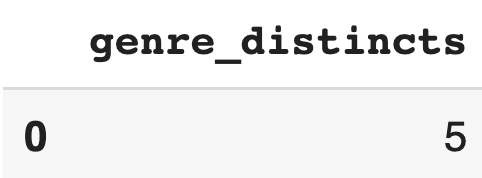

In [ ]:
pd.read_sql("""
SELECT COUNT(*) AS nb_genres
FROM Genre;
""", conn)

,nb_genres
0,5


> 3.4. La bibliothèque souhaite investir dans les auteurs les plus populaires, basé sur le nombre de livres qu'ils ont écrits. Combien de livres a écrit l'auteur le plus prolifique ?

In [ ]:
pd.read_sql("""
SELECT
    Auteur.Prenom,
    Auteur.Nom,
    COUNT(Livre.LivreID) AS nb_livres

FROM Auteur

JOIN Livre
    ON Auteur.AuteurID = Livre.AuteurID

GROUP BY Auteur.AuteurID, Auteur.Prenom, Auteur.Nom

-- Je trie du plus grand au plus petit
ORDER BY nb_livres DESC

-- Je ne garde que le plus prolifique
LIMIT 1;
""", conn)

,Prenom,Nom,nb_livres
0,George,Orwell,2


Résultat attendu:

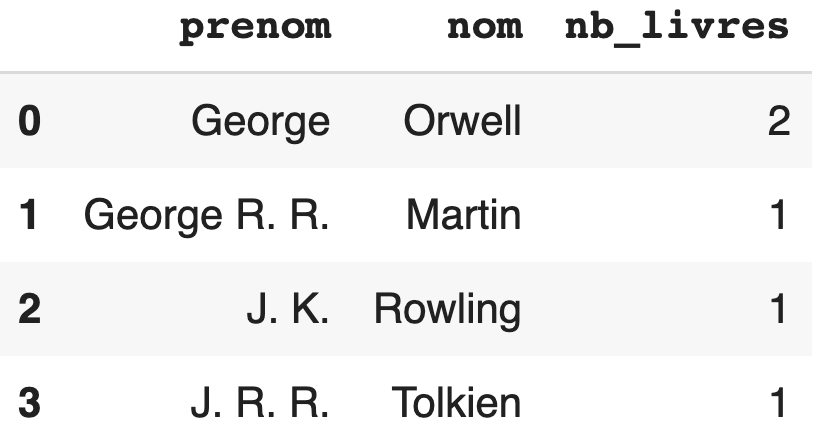

## Interprétation métier

La question demande d’identifier l’auteur le plus prolifique. J’ai donc calculé le nombre de livres par auteur et extrait le maximum.

Cependant, dans une logique métier, se limiter à un seul auteur peut être restrictif. Afin d’orienter une stratégie d’investissement, il serait pertinent d’identifier un groupe d’auteurs prolifiques (top 5 ou top 10), permettant une analyse plus robuste et moins dépendante d’un cas isolé.

In [ ]:
pd.read_sql("""
SELECT
    Auteur.Prenom,
    Auteur.Nom,
    COUNT(Livre.LivreID) AS nb_livres

FROM Auteur

JOIN Livre
    ON Auteur.AuteurID = Livre.AuteurID

GROUP BY Auteur.AuteurID, Auteur.Prenom, Auteur.Nom

ORDER BY nb_livres DESC

LIMIT 10;
""", conn)

,Prenom,Nom,nb_livres
0,George,Orwell,2
1,George R. R.,Martin,1
2,J. K.,Rowling,1
3,J. R. R.,Tolkien,1


> 3.5 : Trouvez les auteurs qui ont écrit plus d'un livre dans plus d'un genre. Classez-les par ordre décroissant du nombre de livres distincts qu'ils ont écrits, puis par ordre décroissant du nombre de genres distincts dans lesquels ils ont écrit ?.

Résultat attendu:

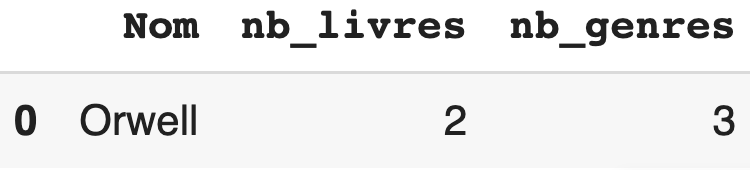

In [ ]:
pd.read_sql("""
SELECT
    Auteur.Prenom,
    Auteur.Nom,

    -- Je compte le nombre de livres distincts écrits par auteur
    COUNT(DISTINCT Livre.LivreID) AS nb_livres,

    -- Je compte le nombre de genres distincts dans lesquels l’auteur a écrit
    COUNT(DISTINCT LivreGenre.GenreID) AS nb_genres

FROM Auteur

-- Liaison auteur → livres
JOIN Livre
    ON Auteur.AuteurID = Livre.AuteurID

-- Liaison livres → genres
JOIN LivreGenre
    ON Livre.LivreID = LivreGenre.LivreID

-- Agrégation par auteur
GROUP BY Auteur.AuteurID, Auteur.Prenom, Auteur.Nom

-- Je filtre :
-- + d’un livre
-- + d’un genre
HAVING
    COUNT(DISTINCT Livre.LivreID) > 1
    AND COUNT(DISTINCT LivreGenre.GenreID) > 1

-- Tri demandé
ORDER BY
    nb_livres DESC,
    nb_genres DESC;
""", conn)

,Prenom,Nom,nb_livres,nb_genres
0,George,Orwell,2,3


---

    

---

# Pandas _(3h30)_


---



# Importation et pré-traitement d'un dataset
---



*Le jeu de données à analyser se trouve à l'adresse suivante : (https://divvy-tripdata.s3.amazonaws.com/index.html). Il y a un fichier par mois, pour un total de 12 fichiers. Chaque fichier contient 13 colonnes avec des types de données variés. Nous allons fusionner les fichiers en un seul et le nommer 'combined_data'.*

In [ ]:
# Importation des bibliothèques
import numpy as np
import pandas as pd
import datetime
import requests
import zipfile
import io
import os
from math import radians, sin, cos, sqrt, atan2

In [ ]:
####### Importation des datasets depuis le serveur AWS dédiéc (A EXECUTER UNE SEULE FOIS !!!!)

# Liste des noms de fichiers
file_names = [
    "202101-divvy-tripdata.zip",
    "202102-divvy-tripdata.zip",
    "202103-divvy-tripdata.zip",
    "202104-divvy-tripdata.zip",
    "202105-divvy-tripdata.zip",
    "202106-divvy-tripdata.zip",
    "202107-divvy-tripdata.zip",
    "202108-divvy-tripdata.zip",
    "202109-divvy-tripdata.zip",
    "202110-divvy-tripdata.zip",
    "202111-divvy-tripdata.zip",
    "202112-divvy-tripdata.zip"
]

# URL de base
base_url = "https://divvy-tripdata.s3.amazonaws.com/"

# Télécharger chaque fichier
for file_name in file_names:

    url = base_url + file_name
    response = requests.get(url)

    # Extraire le fichier Zip dans le dossier local "wild_divvy_data"
    with zipfile.ZipFile(io.BytesIO(response.content)) as the_zip:
      the_zip.extractall("wild_divvy_data")


Je récupère les 12 fichiers mensuels en automatisant le téléchargement via une boucle, puis j’extrais les fichiers ZIP afin d’obtenir les données brutes. Ensuite, je concatène l’ensemble des fichiers dans un seul DataFrame pour constituer une base complète sur l’année.

In [ ]:
folder_path = 'wild_divvy_data'

# Obtenir une liste de tous les fichiers CSV dans le dossier local
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Initialiser un DataFrame vide pour stocker les données combinées
combined_data = pd.DataFrame()

# Parcourir chaque fichier CSV et concaténer ses données au DataFrame combiné
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    data = pd.read_csv(file_path)
    combined_data = pd.concat([combined_data, data], ignore_index=True)

# Afficher les données combinées
combined_data

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,7C00A93E10556E47,electric_bike,2021-11-27 13:27:38,2021-11-27 13:46:38,NaN,NaN,NaN,NaN,41.930000,-87.720000,41.960000,-87.730000,casual
1,90854840DFD508BA,electric_bike,2021-11-27 13:38:25,2021-11-27 13:56:10,NaN,NaN,NaN,NaN,41.960000,-87.700000,41.920000,-87.700000,casual
2,0A7D10CDD144061C,electric_bike,2021-11-26 22:03:34,2021-11-26 22:05:56,NaN,NaN,NaN,NaN,41.960000,-87.700000,41.960000,-87.700000,casual
3,2F3BE33085BCFF02,electric_bike,2021-11-27 09:56:49,2021-11-27 10:01:50,NaN,NaN,NaN,NaN,41.940000,-87.790000,41.930000,-87.790000,casual
4,D67B4781A19928D4,electric_bike,2021-11-26 19:09:28,2021-11-26 19:30:41,NaN,NaN,NaN,NaN,41.900000,-87.630000,41.880000,-87.620000,casual
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5595058,5E5C9CD681E0419C,classic_bike,2021-08-07 18:07:43,2021-08-07 18:21:21,Wells St & Evergreen Ave,TA1308000049,Lincoln Ave & Diversey Pkwy,TA1307000064,41.906724,-87.634830,41.932225,-87.658617,member
5595059,96FB57CF4AA456F6,electric_bike,2021-08-09 08:49:31,2021-08-09 09:03:51,Broadway & Sheridan Rd,13323,Clark St & Lincoln Ave,13179,41.952709,-87.649940,41.915973,-87.634762,member
5595060,226A0910DCCE904C,classic_bike,2021-08-12 16:55:57,2021-08-12 17:15:10,Dearborn St & Adams St,TA1305000005,Clark St & Lincoln Ave,13179,41.879356,-87.629791,41.915689,-87.634600,member
5595061,1A97D27AE23DE1E7,classic_bike,2021-08-08 22:47:43,2021-08-08 23:08:12,Broadway & Sheridan Rd,13323,Clark St & Winnemac Ave,TA1309000035,41.952833,-87.649993,41.973348,-87.667855,casual


Le DataFrame regroupe l’ensemble des trajets de vélos sur une année, chaque ligne représentant une course individuelle avec ses caractéristiques temporelles, géographiques et utilisateur. Je vais le pré-traiter afin

## Compréhension du dataset

La granularité du dataset est au niveau du trajet : chaque ligne correspond à une course individuelle réalisée par un utilisateur.

## Démarche de préparation

Je réalise un pré-traitement des données afin d’effectuer un audit initial du dataset. Cette étape me permet d’identifier les anomalies, les incohérences et les valeurs manquantes.

L’objectif est ensuite de définir des règles de nettoyage adaptées, afin de garantir la qualité et la fiabilité des données avant toute analyse.

Pré-traitement
---



Quelle est la structure du dataset?

In [ ]:
combined_data.shape

(5595063, 13)

Le dataset contient plus de 5,5 millions de lignes, ce qui nécessite une attention particulière sur la performance des traitements et la pertinence des filtrages afin de ne pas altérer la représentativité des données.

1. Afficher les types des colonnes

In [ ]:
combined_data.dtypes

,0
ride_id,object
rideable_type,object
started_at,object
ended_at,object
start_station_name,object
start_station_id,object
end_station_name,object
end_station_id,object
start_lat,float64
start_lng,float64


1.2 Verifier qu'il n'y ait pas d'espaces cachées dans le nom des colomnes

In [ ]:
combined_data.columns.tolist() #OK

['ride_id',
 'rideable_type',
 'started_at',
 'ended_at',
 'start_station_name',
 'start_station_id',
 'end_station_name',
 'end_station_id',
 'start_lat',
 'start_lng',
 'end_lat',
 'end_lng',
 'member_casual']

2. Afficher le nombre de valeurs manquantes par colonne

In [ ]:
# Calcul du nombre et du pourcentage de valeurs manquantes
df_nan = combined_data.isna().sum().to_frame(name="nb_nan")

df_nan["pct_nan"] = (df_nan["nb_nan"] / len(combined_data)) * 100 #J'ajoute le pourcentage pour mieux évaluer l'impact d'une potentielle suppression

# Tri pour une meilleure lisibilité
df_nan = df_nan.sort_values(by="pct_nan", ascending=False)

df_nan

,nb_nan,pct_nan
end_station_name,739170,13.211111
end_station_id,739170,13.211111
start_station_name,690809,12.346760
start_station_id,690806,12.346706
end_lat,4771,0.085272
end_lng,4771,0.085272
started_at,0,0.000000
rideable_type,0,0.000000
ride_id,0,0.000000
ended_at,0,0.000000


## Analyse des valeurs manquantes

Le dataset contient 5 595 063 lignes. Afin d’évaluer l’impact des valeurs manquantes, je calcule leur proportion par colonne.

Les résultats montrent :
- environ 12 à 13 % de valeurs manquantes sur les colonnes liées aux stations,
- moins de 0,1 % sur les coordonnées de fin.

En l’absence de besoin métier explicite, j’adopte une approche pragmatique :
- les colonnes faiblement impactées peuvent être nettoyées par suppression sans altérer la qualité globale,
- les colonnes fortement impactées nécessitent une stratégie de conservation ou d’imputation afin d’éviter une perte significative de données.

Cette étape me permet de prioriser les traitements et de garantir la fiabilité des analyses futures.

3. Identifier et compter les lignes dupliquées pour toutes les colonnes

In [ ]:
combined_data.duplicated().sum() #En l'abscence de doublon, je n'ai pas besoin de code supplémentaire.

np.int64(0)

## Audit initial du dataset

Le dataset contient 5 595 063 lignes, avec une granularité au niveau du trajet (une ligne = une course).

### Vérifications réalisées

- **Valeurs manquantes :**
  - Environ 12 à 13 % de valeurs manquantes sur les colonnes liées aux stations.
  - Moins de 0,1 % sur les coordonnées de fin.
  
- **Doublons :**
  - Aucun doublon détecté dans le dataset.

### Interprétation

Les valeurs manquantes sont principalement concentrées sur les informations de station, ce qui peut s’expliquer par des trajets sans station fixe (ex : vélos en free-floating).

### Stratégie envisagée

- Suppression des lignes pour les colonnes faiblement impactées (coordonnées), avec un impact limité.
- Conservation ou imputation des colonnes fortement impactées afin d’éviter une perte significative de données.

Cette première analyse me permet de définir des règles de nettoyage adaptées et de sécuriser la qualité des données avant les étapes de transformation et d’analyse.

## Traitement

*Commentaire :*

4. Créer une nouvelle dataframe en supprimant tous les trajets avec des valeurs manquantes et afficher le nombre de lignes et de colonnes de la nouvelle dataframe

Afin d’éviter les effets de bord liés aux vues Pandas, je crée explicitement une copie du dataset nettoyé avec .copy(), ce qui garantit la stabilité des transformations.

In [ ]:
df_clean = combined_data.dropna().copy()
df_clean.shape

(4588302, 13)

La suppression de toutes les lignes contenant des valeurs manquantes entraîne une perte importante de données (~12 à 13 %). Cette approche est donc à nuancer selon les besoins métier et pourra être affinée dans les étapes suivantes.

## Colonnes supplémentaires et transformation des données

Nous ajouterons la distance parcourue en kilomètres à partir des latitudes et longitudes de départ et d'arrivée données. Nous utiliserons la formule de Haversine.

Au vu du volume du dataset nettoyé, je modifie la fonction proposée par une fonction véctorisée afin d'optimer les performances de calcul.

In [ ]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371.0  # Rayon de la Terre en kilomètres


    # Convertir la latitude et la longitude de degrés en radians
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)


    # Calculer les différences entre les latitudes et les longitudes
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Formule de Haversine
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


    # Calculer la distance
    distance = R * c

    return distance


5. Ajouter une nouvelle colonne "distance_travelled_km" en appliquant la fonction haversine sur tous les trajets.

> On rappelle le prototype de la fonction haversine(lat1, lon1, lat2, lon2)



In [ ]:
# Création de la colonne distance sur le dataframe nettoyé
df_clean["distance_travelled_km"] = haversine_vectorized(
    df_clean["start_lat"],
    df_clean["start_lng"],
    df_clean["end_lat"],
    df_clean["end_lng"]
)

df_clean

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,distance_travelled_km
45,4CA9676997DAFFF6,classic_bike,2021-11-26 10:27:28,2021-11-26 11:22:13,Michigan Ave & Oak St,13042,Michigan Ave & Oak St,13042,41.900960,-87.623777,41.900960,-87.623777,casual,0.000000
127,F3E84A230AF2D676,classic_bike,2021-11-15 09:35:03,2021-11-15 09:42:08,Clark St & Grace St,TA1307000127,Clark St & Leland Ave,TA1309000014,41.950780,-87.659172,41.967096,-87.667429,casual,1.938472
190,A1F2C92308007968,electric_bike,2021-11-10 16:27:02,2021-11-10 17:04:28,Leamington Ave & Hirsch St,307,Leamington Ave & Hirsch St,307,41.910000,-87.750000,41.910000,-87.750000,casual,0.000000
211,9B871C3B14E9BEC4,classic_bike,2021-11-09 19:51:36,2021-11-09 20:11:17,Desplaines St & Kinzie St,TA1306000003,Desplaines St & Kinzie St,TA1306000003,41.888716,-87.644448,41.888716,-87.644448,casual,0.000000
256,2A81E957DD24A3DC,classic_bike,2021-11-06 19:14:10,2021-11-06 19:33:19,Larrabee St & Armitage Ave,TA1309000006,Michigan Ave & Oak St,13042,41.918084,-87.643749,41.900960,-87.623777,casual,2.521306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5595058,5E5C9CD681E0419C,classic_bike,2021-08-07 18:07:43,2021-08-07 18:21:21,Wells St & Evergreen Ave,TA1308000049,Lincoln Ave & Diversey Pkwy,TA1307000064,41.906724,-87.634830,41.932225,-87.658617,member,3.451657
5595059,96FB57CF4AA456F6,electric_bike,2021-08-09 08:49:31,2021-08-09 09:03:51,Broadway & Sheridan Rd,13323,Clark St & Lincoln Ave,13179,41.952709,-87.649940,41.915973,-87.634762,member,4.273515
5595060,226A0910DCCE904C,classic_bike,2021-08-12 16:55:57,2021-08-12 17:15:10,Dearborn St & Adams St,TA1305000005,Clark St & Lincoln Ave,13179,41.879356,-87.629791,41.915689,-87.634600,member,4.059565
5595061,1A97D27AE23DE1E7,classic_bike,2021-08-08 22:47:43,2021-08-08 23:08:12,Broadway & Sheridan Rd,13323,Clark St & Winnemac Ave,TA1309000035,41.952833,-87.649993,41.973348,-87.667855,casual,2.717493


## Création de la variable distance

Je crée une nouvelle variable `distance_travelled_km` dans le dataframe nettoyé afin de mesurer la distance parcourue pour chaque trajet.

J’utilise la formule de Haversine, qui permet de calculer la distance entre deux points géographiques à partir de leurs coordonnées de départ et d’arrivée.

Cette variable me permet d’enrichir les données pour :
- analyser les comportements de déplacement,
- détecter des valeurs aberrantes,
- comparer la distance parcourue à la durée du trajet.

Compte tenu du volume du dataset, j’utilise une approche vectorisée avec NumPy afin d’améliorer les performances de calcul.

6. Analyser les statistiques concernant la colonne "distance_travelled_km".

Que remarquez vous?

In [ ]:
df_clean["distance_travelled_km"].describe()

,distance_travelled_km
count,4.588302e+06
mean,2.128845e+00
std,1.879802e+00
min,0.000000e+00
25%,9.038498e-01
50%,1.619725e+00
75%,2.814214e+00
max,3.380018e+01


## Analyse de la variable distance_travelled_km

Le dataset contient 4 588 302 trajets après suppression des valeurs manquantes.

### Analyse statistique

- Distance moyenne : 2,13 km  
- Médiane : 1,62 km  
- Écart-type : 1,88 km  

- 25% des trajets font moins de 0,90 km  
- 50% des trajets font moins de 1,62 km  
- 75% des trajets font moins de 2,81 km  

- Distance minimale : 0 km  
- Distance maximale : 33,8 km  

### Interprétation

La majorité des trajets se situe entre 1 et 3 km, ce qui correspond à un usage urbain cohérent.

Cependant, des anomalies sont observées :
- des distances nulles (0 km), incompatibles avec un trajet réel,
- des distances très élevées (jusqu’à 33,8 km), peu représentatives d’un usage standard et potentiellement liées à des erreurs de géolocalisation.

L’écart entre la moyenne (2,13 km) et la médiane (1,62 km) indique une distribution asymétrique, influencée par des valeurs extrêmes.

### Enrichissement du dataset

Afin de fiabiliser l’analyse, j’ajoute une variable `ride_duration_s` correspondant à la durée du trajet en secondes.
Pour cela je dois convertir 'started_at' et 'ended_at' au format datetime afin de pouvoir réaliser le calcul précis de la durée des trajets en secondes.
Cette variable permet de croiser distance et temps pour analyser la cohérence des trajets.
La durée est calculée en secondes afin de faciliter les analyses quantitatives. je réalise en complément une conversion en format lisible (minutes et secondes) pour améliorer l’interprétation.

### Stratégie de nettoyage

Plutôt que de supprimer immédiatement les valeurs aberrantes, j’adopte une approche progressive :

- Identification des trajets incohérents à partir de la distance et de la durée,
- Calcul de la vitesse pour détecter des comportements atypiques,
- Définition de seuils de filtrage basés sur des critères métier (trajets trop courts, trop longs ou irréalistes).

Cette approche permet d’éviter une suppression excessive des données et d’améliorer la fiabilité globale du dataset.

7. Pour remédier à ce problèm, ajouter une nouvelle colonne "ride_duration_s" pour calculer la période du trajet en secondes

In [ ]:
# Conversion en datetime si ce n’est pas déjà fait
df_clean["started_at"] = pd.to_datetime(df_clean["started_at"])
df_clean["ended_at"] = pd.to_datetime(df_clean["ended_at"])

# Création de la durée en secondes
df_clean["ride_duration_s"] = (
    df_clean["ended_at"] - df_clean["started_at"]
).dt.total_seconds()

#Création d'une colonne facilitant l'interprétation
# Conversion vectorisée des secondes en durée lisible HH:MM:SS
duration_td = pd.to_timedelta(df_clean["ride_duration_s"], unit="s")

total_seconds = duration_td.dt.total_seconds().astype("int64")

hours = total_seconds // 3600
minutes = (total_seconds % 3600) // 60
seconds = total_seconds % 60

df_clean["ride_duration_hms"] = (
    hours.astype(str).str.zfill(2) + ":" +
    minutes.astype(str).str.zfill(2) + ":" +
    seconds.astype(str).str.zfill(2)
)

df_clean

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,distance_travelled_km,ride_duration_s,ride_duration_hms
45,4CA9676997DAFFF6,classic_bike,2021-11-26 10:27:28,2021-11-26 11:22:13,Michigan Ave & Oak St,13042,Michigan Ave & Oak St,13042,41.900960,-87.623777,41.900960,-87.623777,casual,0.000000,3285.0,00:54:45
127,F3E84A230AF2D676,classic_bike,2021-11-15 09:35:03,2021-11-15 09:42:08,Clark St & Grace St,TA1307000127,Clark St & Leland Ave,TA1309000014,41.950780,-87.659172,41.967096,-87.667429,casual,1.938472,425.0,00:07:05
190,A1F2C92308007968,electric_bike,2021-11-10 16:27:02,2021-11-10 17:04:28,Leamington Ave & Hirsch St,307,Leamington Ave & Hirsch St,307,41.910000,-87.750000,41.910000,-87.750000,casual,0.000000,2246.0,00:37:26
211,9B871C3B14E9BEC4,classic_bike,2021-11-09 19:51:36,2021-11-09 20:11:17,Desplaines St & Kinzie St,TA1306000003,Desplaines St & Kinzie St,TA1306000003,41.888716,-87.644448,41.888716,-87.644448,casual,0.000000,1181.0,00:19:41
256,2A81E957DD24A3DC,classic_bike,2021-11-06 19:14:10,2021-11-06 19:33:19,Larrabee St & Armitage Ave,TA1309000006,Michigan Ave & Oak St,13042,41.918084,-87.643749,41.900960,-87.623777,casual,2.521306,1149.0,00:19:09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5595058,5E5C9CD681E0419C,classic_bike,2021-08-07 18:07:43,2021-08-07 18:21:21,Wells St & Evergreen Ave,TA1308000049,Lincoln Ave & Diversey Pkwy,TA1307000064,41.906724,-87.634830,41.932225,-87.658617,member,3.451657,818.0,00:13:38
5595059,96FB57CF4AA456F6,electric_bike,2021-08-09 08:49:31,2021-08-09 09:03:51,Broadway & Sheridan Rd,13323,Clark St & Lincoln Ave,13179,41.952709,-87.649940,41.915973,-87.634762,member,4.273515,860.0,00:14:20
5595060,226A0910DCCE904C,classic_bike,2021-08-12 16:55:57,2021-08-12 17:15:10,Dearborn St & Adams St,TA1305000005,Clark St & Lincoln Ave,13179,41.879356,-87.629791,41.915689,-87.634600,member,4.059565,1153.0,00:19:13
5595061,1A97D27AE23DE1E7,classic_bike,2021-08-08 22:47:43,2021-08-08 23:08:12,Broadway & Sheridan Rd,13323,Clark St & Winnemac Ave,TA1309000035,41.952833,-87.649993,41.973348,-87.667855,casual,2.717493,1229.0,00:20:29


8. Analyser les statistiques concernant la colonne "ride_duration_s".

Que remarquez vous?

In [ ]:
desc = df_clean["ride_duration_s"].describe()

desc_readable = pd.DataFrame({
    "secondes": desc.round(0),
    "minutes": (desc / 60).round(2),
    "heures": (desc / 3600).round(2)
})

desc_readable #Je rends la lecture plus lisible pour l'oeil humain

,secondes,minutes,heures
count,4588302.0,76471.70,1274.53
mean,1309.0,21.81,0.36
std,11066.0,184.43,3.07
min,-3354.0,-55.90,-0.93
25%,417.0,6.95,0.12
50%,732.0,12.20,0.20
75%,1327.0,22.12,0.37
max,3356649.0,55944.15,932.40


## Analyse de la durée des trajets

La durée moyenne d’un trajet est d’environ 21 minutes, avec une médiane à 12 minutes, ce qui indique que la majorité des trajets sont relativement courts.

Cependant, la présence de valeurs négatives (jusqu’à -55 minutes) et de durées extrêmement longues (plus de 900 heures) révèle des anomalies importantes dans les données.

Ces résultats confirment la nécessité de mettre en place des règles de filtrage basées sur la cohérence temporelle.

***Nettoyages demandés vs nettoyages effectués***

## Nettoyage des trajets

La consigne demande de supprimer les trajets de moins d’une minute, considérés comme non représentatifs.

Cependant, l’analyse exploratoire a également mis en évidence d’autres anomalies :
- des durées négatives ou nulles,
- des distances nulles.

À ce stade du traitement, je mets en place un premier niveau de nettoyage cohérent avec les variables disponibles :
- suppression des trajets de durée négative ou nulle,
- suppression des trajets de moins d’une minute,
- suppression des distances nulles.

Ce pré-nettoyage permet de sécuriser les données avant la création de nouvelles variables, notamment la vitesse, qui permettra d’affiner le filtrage des anomalies.

In [ ]:
# Suppression des durées négatives ou nulles
df_clean = df_clean[df_clean["ride_duration_s"] > 0]

# Suppression des trajets de moins d'une minute
df_clean = df_clean[df_clean["ride_duration_s"] >= 60]

# Suppression des distances nulles
df_clean = df_clean[df_clean["distance_travelled_km"] > 0]

## Vérification du nettoyage

Je compare le nombre de lignes avant et après filtrage afin de mesurer l’impact du nettoyage.

Je contrôle également qu’il ne reste plus de trajets de moins d’une minute ni de distances nulles, afin de valider l’application correcte des règles définies.

In [ ]:
# Vérification avant / après nettoyage
nb_lignes_avant = len(df_clean)

df_clean = df_clean[
    (df_clean["ride_duration_s"] >= 60) &
    (df_clean["distance_travelled_km"] > 0)
].copy()

nb_lignes_apres = len(df_clean)
nb_lignes_supprimees = nb_lignes_avant - nb_lignes_apres
pct_supprime = round((nb_lignes_supprimees / nb_lignes_avant) * 100, 2)

# Contrôle : il ne doit plus rester de trajets < 60 s ni de distances nulles
print((df_clean["ride_duration_s"] < 60).sum())
print((df_clean["distance_travelled_km"] <= 0).sum())


print(f"Nombre de lignes avant nettoyage : {nb_lignes_avant:,}")
print(f"Nombre de lignes après nettoyage : {nb_lignes_apres:,}")
print(f"Nombre de lignes supprimées : {nb_lignes_supprimees:,}")
print(f"Pourcentage supprimé : {pct_supprime} %") #Le code a tourné 2 fois pour moi mais le dataset est nettoyé selon mes demandes


0
0
Nombre de lignes avant nettoyage : 4,295,746
Nombre de lignes après nettoyage : 4,295,746
Nombre de lignes supprimées : 0
Pourcentage supprimé : 0.0 %


10. Créer une colonne "speed_kph" afin d'analyser la vitesse en calculant la vitesse du km/h vers mph.



## Création de la variable vitesse

Je crée une nouvelle variable `speed_kph` afin de calculer la vitesse moyenne de chaque trajet.

Le calcul est cohérent avec les variables déjà construites :
- `distance_travelled_km` est exprimée en kilomètres,
- `ride_duration_s` est exprimée en secondes.

Je convertis donc la durée en heures avant de calculer la vitesse, afin d’obtenir une mesure en km/h. je choisis de ne pas arrondir pour garder un e précision maximale lors des calculs. Un arrondi pourra être appliqué ultérieurement pour des besoins de visualisation.

Cette variable me permettra d’identifier des trajets incohérents ou atypiques dans les étapes suivantes du nettoyage.

In [ ]:
# Création de la vitesse moyenne du trajet en km/h
df_clean["speed_kph"] = df_clean["distance_travelled_km"] / (df_clean["ride_duration_s"] / 3600)

In [ ]:
df_clean["speed_kph"].describe()

,speed_kph
count,4.295746e+06
mean,9.825560e+00
std,4.326447e+00
min,3.387111e-05
25%,7.303432e+00
50%,1.007067e+01
75%,1.261414e+01
max,6.796607e+01


In [ ]:
#Je cherche à voir plus précisément les valeurs extremes

df_clean["speed_kph"].sort_values(ascending=False).head(10)

,speed_kph
2620968,67.966067
2951061,61.011507
1824463,60.168185
2523694,39.170778
2179519,38.032572
2162781,35.893251
4920293,35.373803
122341,35.100303
1518382,34.153716
2215865,33.935743


11. Supprimer les données avec une vitesse supérieure à 45 km/h (~28 mph, vitesse maximale des vélos aux États-Unis).

Je fixe un seuil maximal de 45 km/h en m’appuyant sur une contrainte métier réaliste : les vélos électriques les plus rapides peuvent atteindre environ 45 km/h.

Au-delà de cette valeur, les vitesses observées sont considérées comme non plausibles pour ce type de mobilité et traduisent probablement des anomalies dans les données (erreurs de durée ou de géolocalisation).

In [ ]:
# Filtrage des vitesses aberrantes (> 45 km/h) + mesure d'impact

nb_avant = len(df_clean)
print(nb_avant)

df_clean = df_clean[df_clean["speed_kph"] <= 45]

nb_apres = len(df_clean)
print(nb_apres)

print(f"Lignes supprimées : {nb_avant - nb_apres} ({round((nb_avant - nb_apres)/nb_avant * 100)}%)") #OK, 3 lignes supprimés. Cohérent avec la cellule précédente

4295746
4295743
Lignes supprimées : 3 (0%)


12. Supprimer les colonnes ("ride_id" et "speed_kph") pour un chargement plus rapide

## Suppression des colonnes non nécessaires

Je supprime les colonnes `ride_id` et `speed_kph` afin d’alléger le dataset.

La colonne `ride_id` n’apporte pas de valeur analytique dans ce contexte, et `speed_kph` a été utilisée uniquement pour identifier les anomalies.

Cette étape permet d’optimiser les performances et de simplifier les analyses futures.

In [ ]:
# Suppression des colonnes inutiles
df_clean = df_clean.drop(columns=["ride_id", "speed_kph"])

In [ ]:
#Verification simple

df_clean.columns.tolist() #OK

['rideable_type',
 'started_at',
 'ended_at',
 'start_station_name',
 'start_station_id',
 'end_station_name',
 'end_station_id',
 'start_lat',
 'start_lng',
 'end_lat',
 'end_lng',
 'member_casual',
 'distance_travelled_km',
 'ride_duration_s',
 'ride_duration_hms']

13. * Supprimer les espaces de fin pour les colonnes de type chaîne de caractères.

  * Il y a des données qui sont des trajets de test (avec 'test' inclus dans le nom de la station et l'identifiant de la station). Nous supprimerons également ces données.

## Traçabilité du nettoyage

J’ajoute des affichages intermédiaires afin de suivre l’impact des transformations sur le dataset. Cela permet de vérifier la cohérence des traitements et de quantifier les données supprimées à chaque étape.

In [ ]:
# Nettoyage des colonnes texte + suppression des trajets de test

print("=== Début nettoyage texte et données de test ===")

# 1. Suppression des espaces
cols_str = df_clean.select_dtypes(include="object").columns
print(f"Colonnes texte détectées : {list(cols_str)}")

df_clean[cols_str] = df_clean[cols_str].apply(lambda col: col.str.strip())

print("Espaces supprimés sur les colonnes texte")

# 2. Suppression des trajets de test
nb_avant = len(df_clean)
print(f"Nombre de lignes avant suppression des tests : {nb_avant:,}")

mask_test = (
    df_clean["start_station_name"].str.contains("test", case=False, na=False) |
    df_clean["end_station_name"].str.contains("test", case=False, na=False) |
    df_clean["start_station_id"].astype(str).str.contains("test", case=False, na=False) |
    df_clean["end_station_id"].astype(str).str.contains("test", case=False, na=False)
)

nb_test = mask_test.sum()
print(f"Nombre de trajets de test détectés : {nb_test:,}")

df_clean = df_clean[~mask_test]

nb_apres = len(df_clean)
print(f"Nombre de lignes après suppression : {nb_apres:,}")

pct_supprime = round((nb_avant - nb_apres) / nb_avant * 100, 2)
print(f"Pourcentage supprimé : {pct_supprime} %")

print("=== Fin nettoyage ===")

=== Début nettoyage texte et données de test ===
Colonnes texte détectées : ['rideable_type', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'member_casual', 'ride_duration_hms']
Espaces supprimés sur les colonnes texte
Nombre de lignes avant suppression des tests : 4,295,743
Nombre de trajets de test détectés : 613
Nombre de lignes après suppression : 4,295,130
Pourcentage supprimé : 0.01 %
=== Fin nettoyage ===


14. Ajouter les catégories suivantes pour découvrir les motifs basés sur le temps :

* day_of_week : Lundi, Mardi, Mercredi, etc.
* day_type : Jour de semaine ou Week-end
* month : Janvier, Février, Mars, etc.
* season : Hiver, Printemps, Été, Automne

    **Créer une fonction pour day_type**

    **Créer une fonction pour season**

In [ ]:
# Traitement 'day_of_week'

# Création de la colonne day_of_week à partir de started_at
df_clean["day_of_week"] = df_clean["started_at"].dt.day_name()

# Traduction en français: réalisation d'un mapping
mapping_days = {
    "Monday": "Lundi",
    "Tuesday": "Mardi",
    "Wednesday": "Mercredi",
    "Thursday": "Jeudi",
    "Friday": "Vendredi",
    "Saturday": "Samedi",
    "Sunday": "Dimanche"
}

df_clean["day_of_week"] = df_clean["day_of_week"].map(mapping_days)

# Vérification
print(df_clean["day_of_week"].value_counts())
print(df_clean[["started_at", "day_of_week"]].head())

day_of_week
Samedi      767638
Dimanche    655854
Vendredi    618482
Mercredi    582419
Mardi       568145
Jeudi       566368
Lundi       536224
Name: count, dtype: int64
             started_at day_of_week
127 2021-11-15 09:35:03       Lundi
256 2021-11-06 19:14:10      Samedi
349 2021-11-18 11:58:24       Jeudi
390 2021-11-23 22:14:11       Mardi
402 2021-11-05 16:48:10    Vendredi


## Création de la variable day_of_week

Je crée une variable `day_of_week` à partir de la date de début du trajet (`started_at`) afin d’identifier le jour de la semaine associé à chaque course.

Cette variable me permettra d’analyser les usages selon les jours et de détecter d’éventuels comportements différents entre semaine et week-end.

In [ ]:
#Traitement de months

# Création du mois à partir de started_at
df_clean["month"] = df_clean["started_at"].dt.month_name()

# Traduction en français: réalisation d'un mapping
mapping_months = {
    "January": "Janvier",
    "February": "Février",
    "March": "Mars",
    "April": "Avril",
    "May": "Mai",
    "June": "Juin",
    "July": "Juillet",
    "August": "Août",
    "September": "Septembre",
    "October": "Octobre",
    "November": "Novembre",
    "December": "Décembre"
}

df_clean["month"] = df_clean["month"].map(mapping_months)

# Vérification
print(df_clean["month"].value_counts())
print(df_clean[["started_at", "month"]].head())

month
Juillet      646000
Août         633146
Septembre    586053
Juin         563812
Octobre      454920
Mai          414384
Avril        273064
Novembre     245626
Mars         188968
Décembre     169492
Janvier       79572
Février       40093
Name: count, dtype: int64
             started_at     month
127 2021-11-15 09:35:03  Novembre
256 2021-11-06 19:14:10  Novembre
349 2021-11-18 11:58:24  Novembre
390 2021-11-23 22:14:11  Novembre
402 2021-11-05 16:48:10  Novembre


## Création de la variable month

Je crée une variable `month` à partir de `started_at` afin d’identifier le mois associé à chaque trajet.

Cette variable permet d’analyser la saisonnalité des usages sur l’année et constitue une base pour la création de variables temporelles plus globales comme les saisons.

#Création de la fonction 'day_type':

-> permet de regrouper les jours en 2 catégories: Jour de la semaine et Week-end

## Création de la variable day_type

Je crée une variable `day_type` afin de regrouper les trajets selon deux catégories : `Jour de semaine` et `Week-end`.

Cette transformation simplifie l’analyse temporelle et permet d’identifier plus facilement des différences d’usage entre mobilité quotidienne et usages de loisir.

In [ ]:
#Fonction et application pour 'day_type'

# Fonction de catégorisation du type de jour
def get_day_type(day_name):
    if day_name in ["Samedi", "Dimanche"]:
        return "Week-end"
    return "Jour de semaine"

# Création de la colonne day_type
df_clean["day_type"] = np.where(
    df_clean["day_of_week"].isin(["Samedi", "Dimanche"]),
    "Week-end",
    "Jour de semaine"
)
# Vérification
print(df_clean["day_type"].value_counts())
print(df_clean[["day_of_week", "day_type"]].drop_duplicates())


day_type
Jour de semaine    2871638
Week-end           1423492
Name: count, dtype: int64
     day_of_week         day_type
127        Lundi  Jour de semaine
256       Samedi         Week-end
349        Jeudi  Jour de semaine
390        Mardi  Jour de semaine
402     Vendredi  Jour de semaine
411     Dimanche         Week-end
1481    Mercredi  Jour de semaine


# Analyse de 'day_type'

## Visualisation du type de jour

Je réalise une visualisation afin d’identifier rapidement les différences d’usage entre les jours de semaine et le week-end.

Un graphique en barres est adapté car il permet de comparer clairement deux catégories distinctes (`Jour de semaine` vs `Week-end`) et de mettre en évidence leur poids relatif.

Ce type de visuel facilite la lecture et la prise de décision par rapport à un tableau de données brutes.

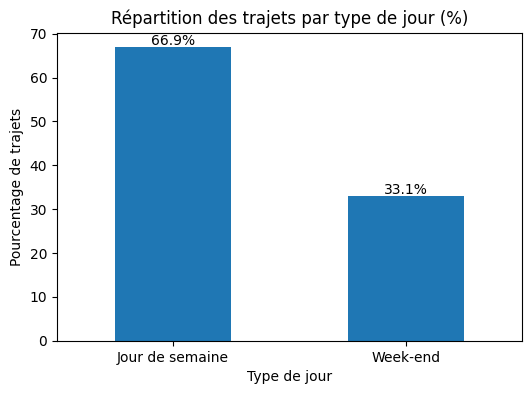

In [ ]:
import matplotlib.pyplot as plt

# Calcul des pourcentages
day_type_pct = (
    df_clean["day_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reindex(["Jour de semaine", "Week-end"])
)

# Graphique
ax = day_type_pct.plot(kind="bar", figsize=(6, 4))

plt.title("Répartition des trajets par type de jour (%)")
plt.xlabel("Type de jour")
plt.ylabel("Pourcentage de trajets")
plt.xticks(rotation=0)

# Ajout des pourcentages
for i, value in enumerate(day_type_pct):
    ax.text(i, value + 0.5, f"{value}%", ha="center")

plt.show()

# Création de la fonction 'season'

-> Permet d'associer chaque mois à une saison

In [ ]:
# Fonction de catégorisation des saisons
def get_season(month_name):
    if month_name in ["Décembre", "Janvier", "Février"]:
        return "Hiver"
    elif month_name in ["Mars", "Avril", "Mai"]:
        return "Printemps"
    elif month_name in ["Juin", "Juillet", "Août"]:
        return "Été"
    else:
        return "Automne"

# Création de la colonne season
df_clean["season"] = np.select(
    [
        df_clean["month"].isin(["Décembre", "Janvier", "Février"]),
        df_clean["month"].isin(["Mars", "Avril", "Mai"]),
        df_clean["month"].isin(["Juin", "Juillet", "Août"]),
    ],
    [
        "Hiver",
        "Printemps",
        "Été"
    ],
    default="Automne"
)

# Vérification
print(df_clean["season"].value_counts())
print(df_clean[["month", "season"]].drop_duplicates().sort_values("month"))

season
Été          1842958
Automne      1286599
Printemps     876416
Hiver         289157
Name: count, dtype: int64
             month     season
4790741       Août        Été
3099438      Avril  Printemps
2095751   Décembre      Hiver
1720799    Février      Hiver
1770430    Janvier      Hiver
3968301    Juillet        Été
360029        Juin        Été
3436696        Mai  Printemps
1867255       Mars  Printemps
127       Novembre    Automne
1089642    Octobre    Automne
2343350  Septembre    Automne


#Analyse de la variables 'Season'

## Visualisation de la saisonnalité des trajets

Je réalise une visualisation afin de faire ressortir rapidement les grandes tendances temporelles du dataset.

Un graphique en barres est adapté ici, car il permet de comparer facilement des catégories distinctes (`Hiver`, `Printemps`, `Été`, `Automne`) et d’identifier immédiatement les écarts de volume entre elles.

Ce type de visuel est plus lisible qu’un tableau brut et facilite l’interprétation pour un décideur.

## Intérêt des pourcentages

Je choisis d’afficher les pourcentages afin de faciliter la lecture et la comparaison entre les catégories.

Contrairement aux volumes bruts, les pourcentages permettent de mesurer le poids relatif de chaque saison dans l’ensemble des trajets.

Cette approche rend la visualisation plus parlante et plus exploitable dans une logique métier.

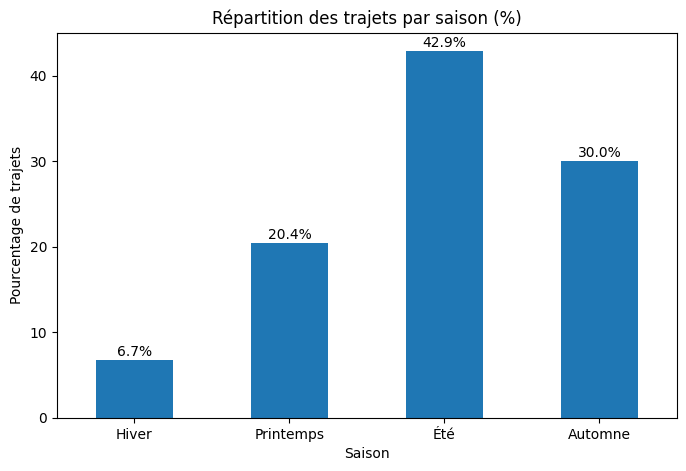

In [ ]:
import matplotlib.pyplot as plt

# Calcul de la répartition en pourcentage
season_pct = (
    df_clean["season"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reindex(["Hiver", "Printemps", "Été", "Automne"])
)

# Création du graphique
ax = season_pct.plot(kind="bar", figsize=(8, 5))

plt.title("Répartition des trajets par saison (%)")
plt.xlabel("Saison")
plt.ylabel("Pourcentage de trajets")
plt.xticks(rotation=0)

# Ajout des pourcentages au-dessus des barres
for i, value in enumerate(season_pct):
    ax.text(i, value + 0.5, f"{value}%", ha="center")

plt.show()

## Conclusion de l’analyse temporelle

L’analyse des variables temporelles met en évidence des tendances claires dans l’usage du service.

→ **Saisonnalité forte**
- Été : 42,9% des trajets  
- Automne : 30,0%  
- Printemps : 20,4%  
- Hiver : 6,7%  

→ L’activité est donc **très fortement concentrée sur les périodes favorables**, avec plus de 70% des trajets entre l’été et l’automne.


→ **Répartition semaine / week-end**
- Jour de semaine : 66,9%  
- Week-end : 33,1%  

→ Le service est majoritairement utilisé pour des **déplacements quotidiens**, mais la part du week-end reste significative.


## Lecture métier

→ Le service présente un **double usage** :
- **Utilitaire** en semaine (travail, déplacements réguliers)
- **Récréatif** le week-end et en période estivale


## Implications opérationnelles

→ Adapter la flotte :
- renforcer la disponibilité en été (≈ 43% de l’activité)
- anticiper la baisse en hiver (≈ 7%)

→ Optimiser la gestion :
- forte demande régulière en semaine
- pics d’usage ponctuels le week-end

→ Piloter la stratégie :
- différencier les usages selon la temporalité
- ajuster les ressources en fonction des saisons



15. Ajouter la colonne 'route_type' pour classifier les trajets comme trajet aller-retour (même 'start_station_name' et 'end_station_name') ou trajet aller simple ('start_station_name' et 'end_station_name' différents) .

## Création de la variable route_type

Je crée une variable `route_type` à l’aide d’une fonction afin de classifier les trajets.

Un trajet est considéré comme aller-retour lorsque la station de départ et la station d’arrivée sont identiques. Dans le cas contraire, il est classé comme aller simple.

Cette variable permet de mieux comprendre les comportements d’usage, notamment la distinction entre trajets utilitaires et trajets de loisir.

Une approche vectorisée est utilisée pour améliorer les performances et car cela est plus adaptée sur le dataset volumineux.

In [ ]:
print("=== Création de la variable route_type ===")

nb_lignes = len(df_clean)
print(f"Nombre de lignes concernées : {nb_lignes:,}")

# Classification vectorisée
df_clean["route_type"] = np.where(
    df_clean["start_station_name"] == df_clean["end_station_name"],
    "Aller-retour",
    "Aller simple"
)

print("Colonne 'route_type' créée avec succès")

print("\nRépartition des types de trajets :")
print(df_clean["route_type"].value_counts())

print("\nPourcentage des types de trajets :")
print((df_clean["route_type"].value_counts(normalize=True) * 100).round(2))

print("\nExemple de vérification :")
print(df_clean[["start_station_name", "end_station_name", "route_type"]].head())

=== Création de la variable route_type ===
Nombre de lignes concernées : 4,295,130
Colonne 'route_type' créée avec succès

Répartition des types de trajets :
route_type
Aller simple    4248096
Aller-retour      47034
Name: count, dtype: int64

Pourcentage des types de trajets :
route_type
Aller simple    98.9
Aller-retour     1.1
Name: proportion, dtype: float64

Exemple de vérification :
              start_station_name             end_station_name    route_type
127          Clark St & Grace St        Clark St & Leland Ave  Aller simple
256   Larrabee St & Armitage Ave        Michigan Ave & Oak St  Aller simple
349        Michigan Ave & Oak St        Michigan Ave & Oak St  Aller-retour
390  Sheridan Rd & Noyes St (NU)  Sheridan Rd & Noyes St (NU)  Aller-retour
402          Clark St & Grace St        Clark St & Leland Ave  Aller simple


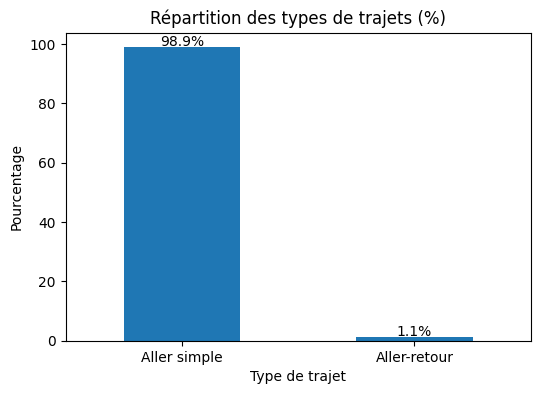

In [ ]:

# Calcul des pourcentages
route_pct = (
    df_clean["route_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reindex(["Aller simple", "Aller-retour"])
)

# Création du graphique
ax = route_pct.plot(kind="bar", figsize=(6, 4))

plt.title("Répartition des types de trajets (%)")
plt.xlabel("Type de trajet")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)

# Ajout des pourcentages sur les barres
for i, value in enumerate(route_pct):
    ax.text(i, value + 0.5, f"{value}%", ha="center")

plt.show()


## Analyse du type de trajet

→ Aller simple : 98,9%  
→ Aller-retour : 1,1%  

### Lecture

→ Les trajets sont très majoritairement des trajets aller simple.  
→ Les trajets aller-retour sont marginaux.

### Interprétation métier

→ Le service est principalement utilisé pour des déplacements d’un point A à un point B (usage utilitaire).

→ Les trajets circulaires (loisir / balade) sont très peu représentés.

### Implication

→ Adapter la gestion des stations :
- forte importance des flux entre stations  
- nécessité d’optimiser le rééquilibrage des vélos

16. Ajouter la colonne "ride_duration_min" qui représente la durée du trajet en minutes.

## Création de la variable ride_duration_min

Je crée une variable `ride_duration_min` afin d’exprimer la durée des trajets en minutes, ce qui est plus lisible et interprétable que les secondes.

Cette variable permet :
- d’analyser la distribution des durées de trajet,
- d’identifier des comportements typiques (trajets courts vs longs),
- de détecter d’éventuelles anomalies restantes.

Elle constitue également une base pour comprendre les usages du service (trajets rapides vs trajets prolongés).

In [ ]:
# Conversion de la durée en minutes
df_clean["ride_duration_min"] = (df_clean["ride_duration_s"] / 60).round(2)

print("Colonne ride_duration_min créée")


# Describe lisible en minutes
desc = df_clean["ride_duration_min"].describe()

desc_readable = desc.round(2)

desc_readable.index = [
    "nb_trajets",
    "moyenne_min",
    "ecart_type_min",
    "min_min",
    "q1_min",
    "mediane_min",
    "q3_min",
    "max_min"
]

print(desc_readable)

Colonne ride_duration_min créée
nb_trajets        4295130.00
moyenne_min            20.18
ecart_type_min        158.23
min_min                 1.00
q1_min                  7.03
mediane_min            12.00
q3_min                 21.03
max_min             55944.15
Name: ride_duration_min, dtype: float64


## Visualisation ciblée des durées de trajets

Le dataset ayant été nettoyé pour exclure les trajets aberrants, je choisis de me concentrer sur les trajets inférieurs à 45 minutes, correspondant aux usages les plus représentatifs.

Ce choix permet d’analyser plus finement la distribution des durées sans être biaisé par des valeurs extrêmes.

Un histogramme permet d’observer la répartition globale, tandis qu’un boxplot synthétise les indicateurs clés (médiane, quartiles, dispersion).

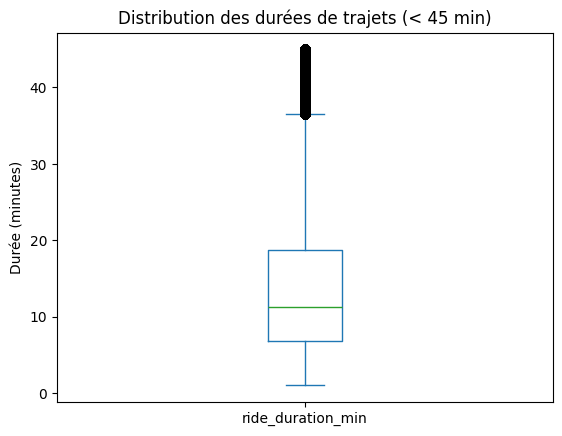

In [ ]:
plt.figure()

df_clean[df_clean["ride_duration_min"] < 45]["ride_duration_min"].plot(kind="box")

plt.title("Distribution des durées de trajets (< 45 min)")
plt.ylabel("Durée (minutes)")

plt.show()

## Analyse de la durée des trajets

→ Médiane ≈ 12 minutes  
→ 50% des trajets entre ≈ 7 et 21 minutes  

### Lecture

→ La majorité des trajets est courte et concentrée sur des durées faibles.  
→ Quelques valeurs plus élevées subsistent mais restent marginales (< 45 min).

### Validation

→ Le boxplot confirme les résultats du `describe` :
- cohérence des quartiles  
- distribution asymétrique (légère traîne à droite)

→ Cette double vérification renforce la fiabilité de l’analyse.

### Conclusion

→ Le service est principalement utilisé pour des trajets courts, typiques d’un usage urbain.

17. Renommer tes colonnes pour qu'elles soient pretes pour la dataViz

## Standardisation des noms de colonnes

Je renomme les colonnes afin de les rendre plus lisibles, homogènes et directement exploitables en data visualisation.

J’utilise des noms courts mais explicites, avec une convention uniforme en anglais et en snake_case. Cela facilite :
- la lecture du dataset,
- la création de mesures et visuels,
- l’exploitation dans des outils comme Power BI ou Python.

Cette étape améliore la clarté du modèle de données et prépare le dataset final à l’analyse.

In [ ]:
print(df_clean.columns)

Index(['rideable_type', 'started_at', 'ended_at', 'start_station_name',
       'start_station_id', 'end_station_name', 'end_station_id', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'member_casual',
       'distance_travelled_km', 'ride_duration_s', 'ride_duration_hms',
       'day_of_week', 'month', 'day_type', 'season', 'route_type',
       'ride_duration_min'],
      dtype='object')


In [ ]:
df_clean = df_clean.rename(columns={
    "rideable_type": "bike_type",
    "started_at": "start_time",
    "ended_at": "end_time",
    "start_station_name": "start_station",
    "start_station_id": "start_station_id",
    "end_station_name": "end_station",
    "end_station_id": "end_station_id",
    "start_lat": "start_latitude",
    "start_lng": "start_longitude",
    "end_lat": "end_latitude",
    "end_lng": "end_longitude",
    "member_casual": "user_type",
    "distance_travelled_km": "distance_km",
    "ride_duration_s": "duration_s",
    "ride_duration_hms": "duration_hms",
    "ride_duration_min": "duration_min"
})

print("=== Colonnes renommées ===")
print(df_clean.columns)

=== Colonnes renommées ===
Index(['bike_type', 'start_time', 'end_time', 'start_station',
       'start_station_id', 'end_station', 'end_station_id', 'start_latitude',
       'start_longitude', 'end_latitude', 'end_longitude', 'user_type',
       'distance_km', 'duration_s', 'duration_hms', 'day_of_week', 'month',
       'day_type', 'season', 'route_type', 'duration_min'],
      dtype='object')


18. Vérifier les caractéristiques des dataframes avant l'export du dataset nettoyé

## Vérification des caractéristiques du dataset

J’utilise la méthode `info()` afin de vérifier la structure du dataset.

Cela me permet de contrôler :
- les types de données de chaque colonne,
- la présence éventuelle de valeurs manquantes,
- la cohérence globale après les étapes de nettoyage et de transformation.

Cette étape valide que le dataset est prêt pour l’analyse et la data visualisation.

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4295130 entries, 127 to 5595062
Data columns (total 21 columns):
 #   Column            Dtype         
---  ------            -----         
 0   bike_type         object        
 1   start_time        datetime64[ns]
 2   end_time          datetime64[ns]
 3   start_station     object        
 4   start_station_id  object        
 5   end_station       object        
 6   end_station_id    object        
 7   start_latitude    float64       
 8   start_longitude   float64       
 9   end_latitude      float64       
 10  end_longitude     float64       
 11  user_type         object        
 12  distance_km       float64       
 13  duration_s        float64       
 14  duration_hms      object        
 15  day_of_week       object        
 16  month             object        
 17  day_type          object        
 18  season            object        
 19  route_type        object        
 20  duration_min      float64       
dtypes: datetime

## Validation finale du dataset

Le dataset final `df_clean` contient 4 295 130 lignes et 21 colonnes.

### Structure des données

- Variables temporelles correctement typées (`start_time`, `end_time` en datetime)
- Variables numériques cohérentes (`distance_km`, `duration_min`, coordonnées)
- Variables catégorielles exploitables (`day_of_week`, `month`, `season`, `route_type`, `user_type`)

### Qualité des données

Les principales étapes de préparation ont été réalisées :
- suppression des valeurs manquantes
- nettoyage des incohérences (durées, distances, vitesses)
- traitement des données de test
- enrichissement avec des variables temporelles et métier

### Conclusion

Le dataset est désormais structuré, cohérent et prêt pour une exploitation en data visualisation ou pour une étape de modélisation.

Il peut être exporté dans un format adapté (CSV, Parquet) pour une utilisation dans des outils comme Power BI, Python ou un pipeline de données.


## Extraire le dataframe pour l'analyse

19. Exporter le dataframe pour l'utiliser par la suite dans ton Notebook d'analyse

## Export du dataset

Le dataset est exporté au format Parquet plutôt qu’en CSV.

Ce choix permet :
- de réduire la taille du fichier grâce à la compression,
- de conserver les types de données (datetime, numériques),
- d’améliorer les performances de lecture.

Ce format est particulièrement adapté à des volumes de données importants et à une utilisation en data analyse ou en data visualisation. L’export au format Parquet permet, notamment lors de l’intégration dans Power BI, de bénéficier de temps de chargement optimisés, de la conservation des types de données et d’une réduction des transformations à effectuer (celles_ci ayant été réalisées en amont), améliorant ainsi les performances globales et la fiabilité des analyses.

In [ ]:
# Installation nécessaire
!pip install pyarrow

# Export en parquet
file_name = '../data/df_cyclistic_clean.parquet'
df_clean.to_parquet(file_name, index=False)

print("Fichier parquet créé")

# Téléchargement sur ma machine
#from google.colab import files
#files.download(file_name)-> dejà effectué donc je l'ai passé en commentaire 

Fichier parquet créé


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Machine learning : Régression et Classification (2h)

Ce notebook est un examen pratique pour évaluer vos compétences en :
- Régression linéaire
- Classification

Complétez chaque section en suivant les consignes données.

## Importer les bibliothèques nécessaires
Importez les bibliothèques pandas, numpy, matplotlib, seaborn et scikit-learn.

In [ ]:
# Correction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

## 1. Régression Linéaire : Prédire `distance_travelled_km`

Sélectionnez les bonnes variables explicatives et entraînez un modèle de régression linéaire.

### Charger les données (CONSEILLE DE LE CHARGER AVEC VISUAL CODE / 2 minutes de chargement environ)
Chargez le fichier CSV depuis l'URL publique et affichez les premières lignes.

## Chargement des données

Le dataset est chargé depuis un fichier Parquet local.

Ce choix permet d’optimiser les performances de lecture et de conserver les types de données, contrairement au format CSV.

Les premières lignes sont affichées afin de vérifier le bon chargement des données.

In [ ]:
# Chargement du fichier parquet local

file_path = '../data/df_cyclistic_clean.parquet'
df = pd.read_parquet(file_path)

# Vérification
print(df.shape)
df.head()

(4295130, 21)


,bike_type,start_time,end_time,start_station,start_station_id,end_station,end_station_id,start_latitude,start_longitude,end_latitude,...,user_type,distance_km,duration_s,duration_hms,day_of_week,month,day_type,season,route_type,duration_min
0,classic_bike,2021-11-15 09:35:03,2021-11-15 09:42:08,Clark St & Grace St,TA1307000127,Clark St & Leland Ave,TA1309000014,41.950780,-87.659172,41.967096,...,casual,1.938472,425.0,00:07:05,Lundi,Novembre,Jour de semaine,Automne,Aller simple,7.08
1,classic_bike,2021-11-06 19:14:10,2021-11-06 19:33:19,Larrabee St & Armitage Ave,TA1309000006,Michigan Ave & Oak St,13042,41.918084,-87.643749,41.900960,...,casual,2.521306,1149.0,00:19:09,Samedi,Novembre,Week-end,Automne,Aller simple,19.15
2,electric_bike,2021-11-18 11:58:24,2021-11-18 12:08:35,Michigan Ave & Oak St,13042,Michigan Ave & Oak St,13042,41.901137,-87.623532,41.901001,...,casual,0.023648,611.0,00:10:11,Jeudi,Novembre,Jour de semaine,Automne,Aller-retour,10.18
3,electric_bike,2021-11-23 22:14:11,2021-11-23 22:44:01,Sheridan Rd & Noyes St (NU),604,Sheridan Rd & Noyes St (NU),604,42.058200,-87.677553,42.058253,...,casual,0.006618,1790.0,00:29:50,Mardi,Novembre,Jour de semaine,Automne,Aller-retour,29.83
4,electric_bike,2021-11-05 16:48:10,2021-11-05 16:53:18,Clark St & Grace St,TA1307000127,Clark St & Leland Ave,TA1309000014,41.950859,-87.659128,41.967070,...,member,1.929563,308.0,00:05:08,Vendredi,Novembre,Jour de semaine,Automne,Aller simple,5.13


In [ ]:
#Vérification 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4295130 entries, 0 to 4295129
Data columns (total 21 columns):
 #   Column            Dtype         
---  ------            -----         
 0   bike_type         str           
 1   start_time        datetime64[ns]
 2   end_time          datetime64[ns]
 3   start_station     str           
 4   start_station_id  str           
 5   end_station       str           
 6   end_station_id    str           
 7   start_latitude    float64       
 8   start_longitude   float64       
 9   end_latitude      float64       
 10  end_longitude     float64       
 11  user_type         str           
 12  distance_km       float64       
 13  duration_s        float64       
 14  duration_hms      str           
 15  day_of_week       str           
 16  month             str           
 17  day_type          str           
 18  season            str           
 19  route_type        str           
 20  duration_min      float64       
dtypes: datetime64[ns](2

## Validation du chargement du dataset

Le chargement du fichier Parquet confirme la cohérence du dataset :

- nombre de lignes conforme aux données nettoyées,
- types de données correctement conservés (datetime, numériques, catégoriels),
- structure identique à celle obtenue après préparation.

Le dataset est donc prêt pour les étapes d’analyse et de modélisation.

### Étape 1: Sélection de lignes de dataframe par condition (Les trajets d'une durée de plus de 5 minutes)

## Filtrage des trajets

Je filtre les trajets d’une durée supérieure à 5 minutes afin d’exclure les trajets très courts, souvent peu représentatifs ou bruités.

Cette étape permet d’améliorer la qualité des données avant la phase de modélisation.

In [ ]:
# Sélection des trajets de plus de 5 minutes
print("=== Filtrage des trajets > 5 minutes ===")

df_ml = df[df["duration_min"] > 5]

print("Nombre de lignes avant :", df.shape[0])
print("Nombre de lignes après :", df_ml.shape[0])
print("Lignes supprimées :", df.shape[0] - df_ml.shape[0])

df_ml.head()

=== Filtrage des trajets > 5 minutes ===
Nombre de lignes avant : 4295130
Nombre de lignes après : 3725630
Lignes supprimées : 569500


,bike_type,start_time,end_time,start_station,start_station_id,end_station,end_station_id,start_latitude,start_longitude,end_latitude,...,user_type,distance_km,duration_s,duration_hms,day_of_week,month,day_type,season,route_type,duration_min
0,classic_bike,2021-11-15 09:35:03,2021-11-15 09:42:08,Clark St & Grace St,TA1307000127,Clark St & Leland Ave,TA1309000014,41.950780,-87.659172,41.967096,...,casual,1.938472,425.0,00:07:05,Lundi,Novembre,Jour de semaine,Automne,Aller simple,7.08
1,classic_bike,2021-11-06 19:14:10,2021-11-06 19:33:19,Larrabee St & Armitage Ave,TA1309000006,Michigan Ave & Oak St,13042,41.918084,-87.643749,41.900960,...,casual,2.521306,1149.0,00:19:09,Samedi,Novembre,Week-end,Automne,Aller simple,19.15
2,electric_bike,2021-11-18 11:58:24,2021-11-18 12:08:35,Michigan Ave & Oak St,13042,Michigan Ave & Oak St,13042,41.901137,-87.623532,41.901001,...,casual,0.023648,611.0,00:10:11,Jeudi,Novembre,Jour de semaine,Automne,Aller-retour,10.18
3,electric_bike,2021-11-23 22:14:11,2021-11-23 22:44:01,Sheridan Rd & Noyes St (NU),604,Sheridan Rd & Noyes St (NU),604,42.058200,-87.677553,42.058253,...,casual,0.006618,1790.0,00:29:50,Mardi,Novembre,Jour de semaine,Automne,Aller-retour,29.83
4,electric_bike,2021-11-05 16:48:10,2021-11-05 16:53:18,Clark St & Grace St,TA1307000127,Clark St & Leland Ave,TA1309000014,41.950859,-87.659128,41.967070,...,member,1.929563,308.0,00:05:08,Vendredi,Novembre,Jour de semaine,Automne,Aller simple,5.13


### Étape 2: Feature Engineering (Choix des variables à conserver)

## Sélection des variables pour la modélisation

La variable cible retenue est `distance_km`, correspondant à la distance parcourue.

Les variables explicatives sont sélectionnées en fonction de leur capacité à expliquer cette distance, notamment les caractéristiques temporelles, géographiques et comportementales.

Je conserve uniquement les colonnes utiles à la modélisation en restructurant le dataset `df_ml`, afin de simplifier le pipeline et d’améliorer la lisibilité.

Une attention particulière est portée à la variable `duration_min`, fortement corrélée à la distance. Elle peut introduire un biais dans le modèle, et son impact sera évalué lors des étapes suivantes.

Cette étape permet de préparer un dataset cohérent et adapté à la phase de modélisation. Mais aussi aux différents modéles de ML.



In [ ]:
# Sélection des variables explicatives
selected_features = [
    'duration_min',
    'start_latitude',
    'start_longitude',
    'end_latitude',
    'end_longitude',
    'day_of_week',
    'month',
    'season',
    'user_type',
    'bike_type'
]

# Écrasement de df_ml avec uniquement les variables utiles + la cible
df_ml = df_ml[selected_features + ['distance_km']]

print("Nouveau shape de df_ml :", df_ml.shape)
print("\nColonnes conservées :")
print(df_ml.columns)

Nouveau shape de df_ml : (3725630, 11)

Colonnes conservées :
Index(['duration_min', 'start_latitude', 'start_longitude', 'end_latitude',
       'end_longitude', 'day_of_week', 'month', 'season', 'user_type',
       'bike_type', 'distance_km'],
      dtype='str')


#Commentaire:

Le dataset `df_ml` est conservé comme base de travail.

Les variables explicatives sont ensuite sélectionnées en fonction du modèle utilisé. Dans le cas de la régression linéaire, seules les variables numériques sont retenues afin de respecter les contraintes de l’algorithme.

Cette approche permet de conserver un pipeline simple, lisible et adaptable.

### Étape 3: Création des variables X et y ( Sélectionne que les variables numériques)

## Séparation des variables

Je sépare les variables explicatives (`X`) de la variable cible (`y`) afin de préparer les données pour la modélisation.

Cette étape est nécessaire pour entraîner le modèle sur les variables d’entrée tout en évaluant sa capacité à prédire la variable cible.

In [ ]:
# Définition des variables X et y
X = df_ml[[
    'duration_min',
    'start_latitude',
    'start_longitude',
    'end_latitude',
    'end_longitude'
]]

y = df_ml['distance_km']

print(X.shape)
print(y.shape)

(3725630, 5)
(3725630,)


### Étape 4: Séparer les jeux d'entraînement et les jeux de test (jeu de test à 20% et random_state = 42)

## Séparation des données

Je sépare les données en un jeu d’entraînement (80%) et un jeu de test (20%).

Le paramètre `random_state=42` permet de garantir la reproductibilité des résultats.

Cette étape est essentielle pour évaluer la capacité du modèle à généraliser sur de nouvelles données.

In [ ]:
from sklearn.model_selection import train_test_split

print("=== Séparation train / test ===")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

=== Séparation train / test ===
X_train : (2980504, 5)
X_test  : (745126, 5)
y_train : (2980504,)
y_test  : (745126,)


### Étape 5: Choisir et importer un algorithme de ML (Algorithme de régression linéaire)

## Choix du modèle

Je choisis un modèle de régression linéaire afin de prédire la variable cible `distance_km`.

Ce modèle est simple à interpréter et permet d’établir une relation linéaire entre les variables explicatives et la distance parcourue.

Il constitue une première approche (baseline) avant l’utilisation éventuelle de modèles plus complexes.

In [ ]:
from sklearn.linear_model import LinearRegression

print("=== Initialisation du modèle ===")

model = LinearRegression()

print("Modèle prêt :", model)

=== Initialisation du modèle ===
Modèle prêt : LinearRegression()


### Étape 6: Entraînement du modèle

In [ ]:
print("\n=== Entraînement du modèle ===")

model.fit(X_train, y_train)

print("Modèle entraîné")


=== Entraînement du modèle ===
Modèle entraîné


### Étape 7: Effectuez les prédictions sur les données de test

In [ ]:
# Prédictions de la distance en km par rapport au jeu de test
print("\n=== Prédictions ===")

y_pred = model.predict(X_test)

print("Prédictions effectuées")


=== Prédictions ===
Prédictions effectuées


### Étape 8: Evaluez le modèle et intéprétez les résultats

Calculez le coefficient de détermination R² pour le jeu d'entrainement et puis pour le jeu de test

## Évaluation du modèle

Le modèle est évalué à l’aide du coefficient de détermination (R²), qui mesure la capacité du modèle à expliquer la variance de la variable cible:
-si R² test proche -> bon modèle
-Si train >> test -> overfitting

La performance est mesurée sur le jeu d’entraînement et le jeu de test afin d’évaluer la capacité de généralisation du modèle.

In [ ]:
# Calcul du R²
r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)

print(f"R² sur le jeu d'entraînement : {r2_train}")
print(f"R² sur le jeu de test : {r2_test}")

R² sur le jeu d'entraînement : 0.013890926938570969
R² sur le jeu de test : 0.012838546905910686


Interprètez les résultats et vérifiez est ce que le modèle à un problème de surajustement(over-fitting) ou sousajustement(under-fitting), commentez votre constatation.

## Évaluation du modèle

Le coefficient de détermination est très faible, avec des valeurs proches de 0 sur les jeux d’entraînement et de test.

Cela indique que le modèle explique très peu la variance de la variable cible `distance_km`. 

Les variables sélectionnées ne permettent donc pas de modéliser efficacement la distance parcourue dans le cadre d’une régression linéaire.

La proximité des scores entre le jeu d’entraînement et le jeu de test suggère l’absence d’overfitting, mais confirme également que le modèle est globalement peu performant.

Ces résultats indiquent que la relation entre les variables explicatives et la distance n’est probablement pas linéaire ou nécessite des transformations supplémentaires.

Des modèles plus complexes ou un travail de feature engineering pourraient être envisagés pour améliorer les performances.

La variable duration_min étant corrélée à la distance, sa suppression devrait théoriquement dégrader les performances. 
Cependant, au vu du faible R² obtenu, son impact réel semble limité dans le cadre de ce modèle linéaire.

## Test de sensibilité de la variable `duration_min`

Je compare deux modèles de régression linéaire : l’un avec la variable `duration_min`, l’autre sans cette variable.

L’objectif est d’évaluer si cette variable améliore réellement la performance du modèle ou si son impact reste limité.

Cette comparaison permet d’identifier le poids réel de `duration_min` dans l’explication de la distance parcourue.

In [ ]:
print("=== Test comparatif : avec / sans duration_min ===")

# Cible
y = df_ml['distance_km']

# Split unique basé sur un index commun
X_full = df_ml[[
    'duration_min',
    'start_latitude',
    'start_longitude',
    'end_latitude',
    'end_longitude'
]]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

# -----------------------------
# 1. Modèle avec duration_min
# -----------------------------
model_with = LinearRegression()
model_with.fit(X_train_full, y_train)

r2_train_with = model_with.score(X_train_full, y_train)
r2_test_with = model_with.score(X_test_full, y_test)

print("\n--- AVEC duration_min ---")
print(f"R² train : {r2_train_with:.4f}")
print(f"R² test  : {r2_test_with:.4f}")

# -----------------------------
# 2. Modèle sans duration_min
# -----------------------------
X_train_wo = X_train_full.drop(columns=['duration_min'])
X_test_wo = X_test_full.drop(columns=['duration_min'])

model_without = LinearRegression()
model_without.fit(X_train_wo, y_train)

r2_train_without = model_without.score(X_train_wo, y_train)
r2_test_without = model_without.score(X_test_wo, y_test)

print("\n--- SANS duration_min ---")
print(f"R² train : {r2_train_without:.4f}")
print(f"R² test  : {r2_test_without:.4f}")

# -----------------------------
# 3. Comparaison
# -----------------------------
print("\n--- Comparaison ---")
print(f"Écart de R² test : {r2_test_with - r2_test_without:.4f}")

=== Test comparatif : avec / sans duration_min ===

--- AVEC duration_min ---
R² train : 0.0139
R² test  : 0.0128

--- SANS duration_min ---
R² train : 0.0111
R² test  : 0.0109

--- Comparaison ---
Écart de R² test : 0.0019


→ La variable `duration_min` améliore légèrement les performances du modèle, mais son impact reste très limité.

→ Le modèle explique globalement très peu la variance de la distance parcourue, quel que soit le jeu de variables utilisé.

On affiche ici un scatterplot montrant l'écart entre valeurs réelles et valeurs prédites.

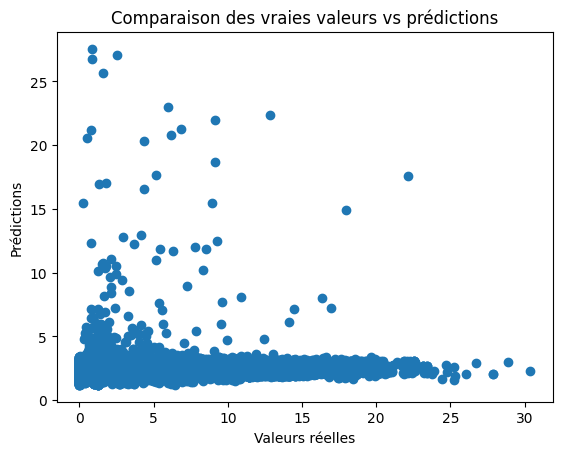

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Comparaison des vraies valeurs vs prédictions")
plt.show()




## Analyse des prédictions du modèle

Le graphique comparant les valeurs réelles aux valeurs prédites met en évidence une forte dispersion des points.

### Observations

→ Les prédictions sont concentrées sur une plage restreinte  
→ Le modèle ne suit pas la variabilité des valeurs réelles  
→ Absence de relation linéaire visible entre prédictions et réalité  

### Interprétation

→ Le modèle ne parvient pas à capturer la relation entre les variables explicatives et la distance parcourue  
→ Les erreurs de prédiction sont importantes, notamment pour les valeurs élevées  

### Conclusion

→ La régression linéaire est inadaptée pour ce problème  
→ Le modèle sous-ajuste les données (underfitting)  
→ Une approche plus complexe ou non linéaire est nécessaire pour améliorer les performances

Calculez la racine de l'erreur quadratique moyenne (RMSE), que pouvez vous intépréter de ce résultat ?

# Calcul deux métriques d'erreur pour quantifier la qualité des prédictions.

RMSE = racine de l'erreur quadratique moyenne → pénalise fort les grosses erreurs
MAE = moyenne des écarts absolus → erreur moyenne "brute" en km

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Racine de l'erreur quadratique moyenne (RMSE): {rmse}")

Racine de l'erreur quadratique moyenne (RMSE): 1.8665413252580287


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Moyenne des écarts absolus : {mae}")


Moyenne des écarts absolus : 1.327807150667104


Votre intéprétation :

In [ ]:
## Interprétation du RMSE et du MAE

Mes deux métriques mesurent l'erreur moyenne de prédiction, exprimée dans l'unité de ma cible (km).

### Résultats

→ **RMSE = 1.87 km** : en moyenne, mes prédictions s'écartent de 1,87 km de la réalité (avec pénalité sur les grosses erreurs)  
→ **MAE = 1.33 km** : l'écart absolu moyen est de 1,33 km par trajet  

### Interprétation

→ L'écart **RMSE (1.87) > MAE (1.33)** révèle la présence de **grosses erreurs ponctuelles** (outliers visibles sur le scatter plot à 25+ km)  
→ Sur des trajets variant de **0 à 30 km**, une erreur moyenne de **1,3 km reste modérée en valeur absolue**  
→ Couplé au R² proche de 0, cela confirme que le modèle prédit quasiment toujours la **même valeur moyenne (~3 km)**  

### Conclusion

→ Les faibles MAE/RMSE sont **trompeurs** : la majorité des trajets sont courts, ce qui limite mécaniquement l'erreur  
→ Le modèle n'apprend pas, il prédit la moyenne  
→ **La régression linéaire avec ces features est inadaptée**

Calculez la corrélation entre `distance_travelled_km` et les autres variables

Je calcule les corrélations entre distance_travelled_km et les autres variables numériques pour identifier les features les plus liées à ma cible.

In [ ]:
correlation_matrix = df_ml.corr(numeric_only=True)
print(correlation_matrix['distance_km'].sort_values(ascending=False))

distance_km        1.000000
end_latitude       0.097785
start_latitude     0.087700
duration_min       0.049762
start_longitude   -0.073358
end_longitude     -0.082276
Name: distance_km, dtype: float64


# Heatmap de corrélation ciblée sur distance_km:

->Une heatmap colonne = lecture visuelle rapide des corrélations
->Je garde le tri décroissant pour hiérarchiser les features
->Plus parlant qu'une matrice complète quand on cible une seule variable

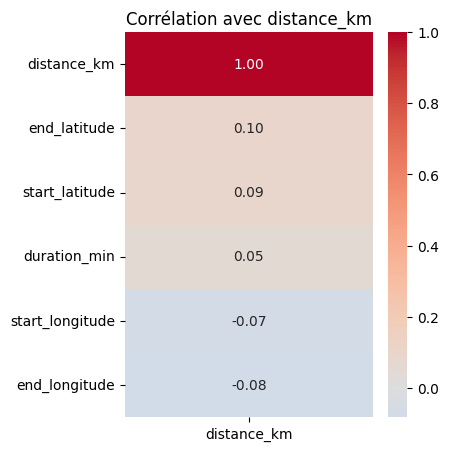

In [ ]:
# Je garde uniquement la colonne distance_km, triée
corr_distance = correlation_matrix[['distance_km']].sort_values(by='distance_km', ascending=False)

plt.figure(figsize=(4, 5))
sns.heatmap(corr_distance, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Corrélation avec distance_km")
plt.show()

Pouvez-vous expliquer la faible performance en regardant les corrélations entre la variable `distance_travelled_km` et les autres variables

In [ ]:
## Explication de la faible performance via les corrélations

La heatmap révèle pourquoi mon modèle échoue à prédire la distance des trajets vélo entre stations : **aucune variable explicative n'est corrélée linéairement à `distance_km`**.

### Lecture des corrélations

→ **end_latitude : 0.10** et **start_latitude : 0.09** → corrélations quasi nulles  
→ **duration_min : 0.05** → la durée du trajet n'est pas liée linéairement à la distance  
→ **start_longitude : -0.07** et **end_longitude : -0.08** → négligeables  

### Pourquoi le modèle échoue

→ La régression linéaire cherche une **combinaison linéaire pondérée** des features pour prédire la cible  
→ Toutes mes corrélations sont **comprises entre -0.08 et 0.10** : aucun signal linéaire exploitable  
→ Le modèle ne trouve aucun coefficient capable d'expliquer la variance de `distance_km`  
→ Résultat logique : **R² ≈ 0** et prédictions écrasées sur la moyenne  

### Pourquoi `duration_min` n'est pas corrélée

→ La vitesse du cycliste varie fortement (niveau physique, dénivelé, feux, pauses)  
→ Un trajet de 10 min peut faire 1 km (zone urbaine dense) comme 4 km (piste cyclable fluide)  
→ Un usager peut aussi **s'arrêter** pendant le trajet sans rendre le vélo  

### Pourquoi les coordonnées brutes ne fonctionnent pas

→ La latitude/longitude d'**une seule station** (départ **ou** arrivée) ne dit rien sur la distance parcourue  
→ C'est la **différence entre les deux stations** qui détermine la distance du trajet  
→ Le modèle linéaire traite chaque coordonnée indépendamment, il ne peut pas "soustraire" deux points  

### Conclusion

→ Sans feature engineering (**delta_lat, delta_lon, distance à vol d'oiseau entre stations**), la régression linéaire est condamnée à échouer  
→ La distance d'un trajet vélo dépend de la **géométrie entre stations**, pas des coordonnées absolues
-> Pour améliorer le modéle, il faudrait réaliser un feature engineering géographique et encoder les varables catégorielles pour les rendre exploitables

#### **HORS CERTIFICATION ( ⚠⚠ Executer le code après avoir fini tout l'examen blanc ⚠⚠)**

Ceci n'est pas inclus dans le programme de la certification mais vous permet de comprendre coment résoudre la performance de votre modèle de régression linéaire




La solution serait de choisir un autre modèle qui serait plus puissant à gérer les problématiques de non linéarité des variables et qui pourrait mieux capturer les relations.
On a pris comme exemple le `RandomForestRegressor`, il devrait prendre autour de 2 mins selon les performances de votre machine.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Création du modèle avec des hyperparamètres optimisés
model = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)

# Entraînement du modèle
model.fit(X_train, y_train)

# Évaluation du modèle sur le jeu de test
r2_score_test = model.score(X_test, y_test)

print(f"R² avec Random Forest : {r2_score_test:.4f}")


R² avec Random Forest : 0.8506


### Étape 9: Expliquer et vulgariser le principe de l'algorithme ML de régression linéaire.


### Principe général

→ La régression linéaire cherche à **prédire une valeur numérique** (ici `distance_km`) à partir d'autres variables (durée, coordonnées...)  
→ Elle trace une **droite** (ou un plan en plusieurs dimensions) qui passe au plus près de tous les points  
→ Formule : **y = a₁·x₁ + a₂·x₂ + ... + b**  

### Analogie simple

→ Il suffit d'imaginer un nuage de points sur un graphique  
→ le modéle va chercher la **ligne droite qui passe le mieux au milieu** de ce nuage  
→ Cette ligne lui permet ensuite de **prédire** une nouvelle valeur à partir d'un nouveau point  

### Comment le modèle "apprend"

→ Il teste plein de droites possibles  
→ Pour chaque droite, il mesure l'**écart entre les points réels et la droite** (erreur)  
→ Il garde la droite qui **minimise la somme des erreurs au carré** (méthode des moindres carrés)  
→ Les **coefficients** (a₁, a₂...) indiquent le poids de chaque variable dans la prédiction  

### Vocabulaire clé

→ **Variable cible (y)** : ce que je veux prédire  
→ **Features (X)** : les variables qui servent à prédire  
→ **Coefficients** : l'importance de chaque feature  
→ **Intercept (b)** : la valeur de base quand toutes les features sont à 0  

### Quand l'utiliser

→ **Oui** : relation linéaire claire entre X et y (ex : surface d'un appartement → prix)  
→ **Non** : relations non linéaires, données avec beaucoup d'outliers, variables catégorielles non encodées  

### Avantages

→ **Simple** à comprendre et à expliquer  
→ **Rapide** à entraîner, même sur de gros volumes  
→ **Interprétable** : les coefficients montrent l'impact de chaque variable  

### Limites

→ Suppose une **relation linéaire** entre X et y  
→ Sensible aux **valeurs aberrantes**  
→ Ne capte pas les **interactions complexes** entre variables  
→ Si les features sont mal corrélées à la cible → **R² proche de 0**

### Étape 10: Les limites et les biais des méthodes utilisées en ML

## Problématiques ML : Underfitting, Overfitting et Optimisation

### Underfitting (sous-ajustement)

→ Le modèle est **trop simple** pour capturer la complexité des données  
→ Il **sous-performe à la fois sur le train et le test** (scores bas partout)  
→ **Symptômes** : R² faible, erreurs élevées, prédictions écrasées sur la moyenne  
→ **Exemple** : mon modèle actuel qui prédit ~3 km pour tous les trajets  
→ **Causes** : features peu informatives, modèle trop basique (linéaire sur données non linéaires)  

### Overfitting (sur-ajustement)

→ Le modèle **apprend par cœur** les données d'entraînement, bruit inclus  
→ Il **performe très bien sur le train mais mal sur le test** (gros écart entre les deux)  
→ **Symptômes** : R² train ≈ 0.99, R² test ≈ 0.40  
→ **Exemple** : un arbre de décision trop profond qui mémorise chaque trajet individuellement  
→ **Causes** : modèle trop complexe, trop de features, pas assez de données  

### Optimisation : comment améliorer un modèle

**1. Agir sur les données**
→ **Feature engineering** : créer de nouvelles variables pertinentes  
→ **Nettoyage** : supprimer outliers, gérer les valeurs manquantes  
→ **Encodage** : transformer les variables catégorielles (one-hot, label encoding)  
→ **Normalisation / standardisation** : mettre les features sur la même échelle  

**2. Agir sur le modèle**
→ **Changer d'algorithme** : passer d'une régression linéaire à Random Forest, XGBoost...  
→ **Régularisation** (Ridge, Lasso) : pénaliser les coefficients trop élevés pour éviter l'overfitting  

**3. Valider correctement**
→ **Cross-validation** : tester le modèle sur plusieurs découpages train/test  
→ **Comparer plusieurs modèles** sur les mêmes métriques (R², RMSE, MAE)  
→ **Analyser les erreurs** : où le modèle se trompe-t-il le plus ?  

### Règle à retenir

→ **Underfitting** = modèle trop simple → **complexifier**  
→ **Overfitting** = modèle trop complexe → **simplifier / régulariser**  
→ L'objectif : trouver le **juste équilibre** (biais-variance)

## 2. Classification : Régression Logistique
Entraînez un modèle de régression logistique pour classifier le type de l'utilisateur (la variable `user_type`).

### Charger les données
Chargez le fichier CSV depuis l'URL publique et affichez les premières lignes.

Je charge le dataset nettoyé par chunks (bonne pratique pour les gros fichiers : évite de saturer la RAM).

In [ ]:
# Correction
file_url = "https://storage.googleapis.com/dataset-storage-chicago-cyclist-csv/cyclistic_clean.csv"
chunk_size = 500000  # Nombre de lignes par chunk
chunks = pd.read_csv(file_url, chunksize=chunk_size)

df_list = []
for chunk in chunks: # Ex. filtrer les trajets avec distance > 0
    df_list.append(chunk)

df_clean = pd.concat(df_list, ignore_index=True)
df_clean.head()

,bike_type,user_type,start_time,end_time,day_of_week,day_type,month,season,start_station_name,end_station_name,route_type,start_lat,start_lng,end_lat,end_lng,distance_travelled_km,ride_duration_s,ride_duration_min
0,classic_bike,member,2021-01-24 19:15:38,2021-01-24 19:22:51,Sunday,Weekend,January,Winter,California Ave & Cortez St,Wood St & Augusta Blvd,One-way trip,41.900363,-87.696704,41.899181,-87.672200,2.032303,433.0,7.216667
1,electric_bike,member,2021-01-23 12:57:38,2021-01-23 13:02:10,Saturday,Weekend,January,Winter,California Ave & Cortez St,California Ave & North Ave,One-way trip,41.900406,-87.696733,41.910435,-87.696890,1.115287,272.0,4.533333
2,electric_bike,casual,2021-01-09 15:28:04,2021-01-09 15:37:51,Saturday,Weekend,January,Winter,California Ave & Cortez St,Wood St & Augusta Blvd,One-way trip,41.900374,-87.696688,41.899180,-87.672178,2.032911,587.0,9.783333
3,electric_bike,casual,2021-01-09 15:28:57,2021-01-09 15:37:54,Saturday,Weekend,January,Winter,California Ave & Cortez St,Wood St & Augusta Blvd,One-way trip,41.900379,-87.696716,41.899149,-87.672177,2.035544,537.0,8.950000
4,classic_bike,casual,2021-01-24 15:56:59,2021-01-24 16:07:08,Sunday,Weekend,January,Winter,California Ave & Cortez St,Wood St & Augusta Blvd,One-way trip,41.900363,-87.696704,41.899181,-87.672200,2.032303,609.0,10.150000


#Copie du DataFrame pour la classification

Je crée une copie dédiée pour la régression logistique. Ça me permet de manipuler les données sans toucher à df_clean.

In [ ]:
# Faisons une copie du DataFrame
df_class = df_clean.copy()
df_class.head()

,bike_type,user_type,start_time,end_time,day_of_week,day_type,month,season,start_station_name,end_station_name,route_type,start_lat,start_lng,end_lat,end_lng,distance_travelled_km,ride_duration_s,ride_duration_min
0,classic_bike,member,2021-01-24 19:15:38,2021-01-24 19:22:51,Sunday,Weekend,January,Winter,California Ave & Cortez St,Wood St & Augusta Blvd,One-way trip,41.900363,-87.696704,41.899181,-87.672200,2.032303,433.0,7.216667
1,electric_bike,member,2021-01-23 12:57:38,2021-01-23 13:02:10,Saturday,Weekend,January,Winter,California Ave & Cortez St,California Ave & North Ave,One-way trip,41.900406,-87.696733,41.910435,-87.696890,1.115287,272.0,4.533333
2,electric_bike,casual,2021-01-09 15:28:04,2021-01-09 15:37:51,Saturday,Weekend,January,Winter,California Ave & Cortez St,Wood St & Augusta Blvd,One-way trip,41.900374,-87.696688,41.899180,-87.672178,2.032911,587.0,9.783333
3,electric_bike,casual,2021-01-09 15:28:57,2021-01-09 15:37:54,Saturday,Weekend,January,Winter,California Ave & Cortez St,Wood St & Augusta Blvd,One-way trip,41.900379,-87.696716,41.899149,-87.672177,2.035544,537.0,8.950000
4,classic_bike,casual,2021-01-24 15:56:59,2021-01-24 16:07:08,Sunday,Weekend,January,Winter,California Ave & Cortez St,Wood St & Augusta Blvd,One-way trip,41.900363,-87.696704,41.899181,-87.672200,2.032303,609.0,10.150000


In [ ]:
# Je vérifie la taille et les colonnes
df_class.info()

<class 'pandas.DataFrame'>
RangeIndex: 4528312 entries, 0 to 4528311
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   bike_type              str    
 1   user_type              str    
 2   start_time             str    
 3   end_time               str    
 4   day_of_week            str    
 5   day_type               str    
 6   month                  str    
 7   season                 str    
 8   start_station_name     str    
 9   end_station_name       str    
 10  route_type             str    
 11  start_lat              float64
 12  start_lng              float64
 13  end_lat                float64
 14  end_lng                float64
 15  distance_travelled_km  float64
 16  ride_duration_s        float64
 17  ride_duration_min      float64
dtypes: float64(7), str(11)
memory usage: 1.2 GB


In [ ]:
## Passage à la classification : régression logistique

### Contexte

→ La régression linéaire sur `distance_km` a échoué (R² ≈ 0)  
→ Je change d'approche : **classification binaire** plutôt que prédiction numérique  
→ Objectif : prédire une **catégorie** à partir des caractéristiques du trajet  

### Audit express du dataset

**Volumétrie**
→ **4.5M de lignes** × 18 colonnes, 1.2 GB en mémoire  
→ Prévoir un **échantillonnage** pour accélérer les calculs si besoin  

**Types de données**
→ **11 colonnes `str`** (catégorielles + temporelles)  
→ **7 colonnes `float64`** (coordonnées, durées, distance)  

### Choix de la variable cible

→ **`user_type`** (`member` / `casual`) → cible binaire idéale et pertinente métier  
→ Enjeu business : identifier les **profils casual** susceptibles de devenir **members**  

### Features disponibles

→ **Numériques** : `start_lat`, `start_lng`, `end_lat`, `end_lng`, `distance_travelled_km`, `ride_duration_min`  
→ **Catégorielles** : `bike_type`, `day_of_week`, `season`, `route_type`, `day_type`  
→ **À écarter** : noms de stations (trop de modalités), timestamps bruts  

### Points d'attention

→ Vérifier les **NaN** et **doublons**  
→ Vérifier l'**équilibre des classes** (`member` vs `casual`) → risque de déséquilibre  
→ Encoder les variables catégorielles avant modélisation  

### Prochaines étapes

→ 1. Vérifier la répartition de `user_type`  
→ 2. Nettoyer / encoder les features  
→ 3. Entraîner la régression logistique  
→ 4. Évaluer (accuracy, matrice de confusion, précision, rappel, F1)

### Étape 1: Sélection de lignes de dataframe par condition (Les trajets d'une durée de plus de 10 minutes)

Je filtre pour garder uniquement les trajets pertinents (>10 min) afin d'écarter les trajets anormalement courts.

In [ ]:
df_class = df_class[df_class['ride_duration_min'] > 10]
df_class.head()

,bike_type,user_type,start_time,end_time,day_of_week,day_type,month,season,start_station_name,end_station_name,route_type,start_lat,start_lng,end_lat,end_lng,distance_travelled_km,ride_duration_s,ride_duration_min
4,classic_bike,casual,2021-01-24 15:56:59,2021-01-24 16:07:08,Sunday,Weekend,January,Winter,California Ave & Cortez St,Wood St & Augusta Blvd,One-way trip,41.900363,-87.696704,41.899181,-87.672200,2.032303,609.0,10.150000
5,electric_bike,member,2021-01-22 15:15:28,2021-01-22 15:36:01,Friday,Weekday,January,Winter,California Ave & Cortez St,Wells St & Elm St,One-way trip,41.900373,-87.696790,41.903272,-87.634457,5.168809,1233.0,20.550000
8,electric_bike,member,2021-01-27 07:27:09,2021-01-27 07:45:32,Wednesday,Weekday,January,Winter,California Ave & Cortez St,Damen Ave & Clybourn Ave,One-way trip,41.900313,-87.696792,41.931841,-87.677814,3.841371,1103.0,18.383333
9,electric_bike,member,2021-01-15 08:54:41,2021-01-15 09:11:46,Friday,Weekday,January,Winter,California Ave & Cortez St,Damen Ave & Clybourn Ave,One-way trip,41.900356,-87.696627,41.931922,-87.677856,3.838230,1025.0,17.083333
14,classic_bike,casual,2021-01-22 21:54:15,2021-01-22 22:04:27,Friday,Weekday,January,Winter,California Ave & Cortez St,Honore St & Division St,One-way trip,41.900363,-87.696704,41.903119,-87.673935,1.909151,612.0,10.200000


### Étape 2: Feature Engineering (Choix des variables à conserver)

Gardez que ces colonnes dans votre dataframe :

`['distance_travelled_km', 'ride_duration_min', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'month', 'season', 'user_type', 'bike_type']`


In [ ]:
selected_features = ['distance_travelled_km', 'ride_duration_min', 'start_lat', 'start_lng',
                     'end_lat', 'end_lng', 'month', 'season', 'user_type', 'bike_type']
df_class = df_class[selected_features]
df_class.head()

,distance_travelled_km,ride_duration_min,start_lat,start_lng,end_lat,end_lng,month,season,user_type,bike_type
4,2.032303,10.150000,41.900363,-87.696704,41.899181,-87.672200,January,Winter,casual,classic_bike
5,5.168809,20.550000,41.900373,-87.696790,41.903272,-87.634457,January,Winter,member,electric_bike
8,3.841371,18.383333,41.900313,-87.696792,41.931841,-87.677814,January,Winter,member,electric_bike
9,3.838230,17.083333,41.900356,-87.696627,41.931922,-87.677856,January,Winter,member,electric_bike
14,1.909151,10.200000,41.900363,-87.696704,41.903119,-87.673935,January,Winter,casual,classic_bike


### Étape 3: Création des variables X et y ( Sélectionne que les variables numériques)

J'encode user_type (ma cible) et bike_type (feature) en binaire avec LabelEncoder.

LabelEncoder transforme chaque modalité en entier (0, 1, 2...)
Pour user_type : casual → 0, member → 1 (ou inverse selon l'ordre alphabétique)
Pour bike_type : chaque type de vélo devient un entier

In [ ]:
from sklearn.preprocessing import LabelEncoder

# J'encode user_type (variable cible)
le_user = LabelEncoder()
df_class['user_type'] = le_user.fit_transform(df_class['user_type'])

# J'encode bike_type (feature)
le_bike = LabelEncoder()
df_class['bike_type'] = le_bike.fit_transform(df_class['bike_type'])

print("Mapping user_type :", dict(zip(le_user.classes_, le_user.transform(le_user.classes_))))
print("Mapping bike_type :", dict(zip(le_bike.classes_, le_bike.transform(le_bike.classes_))))
df_class.head()

Mapping user_type : {'casual': np.int64(0), 'member': np.int64(1)}
Mapping bike_type : {'classic_bike': np.int64(0), 'docked_bike': np.int64(1), 'electric_bike': np.int64(2)}


,distance_travelled_km,ride_duration_min,start_lat,start_lng,end_lat,end_lng,month,season,user_type,bike_type
4,2.032303,10.150000,41.900363,-87.696704,41.899181,-87.672200,January,Winter,0,0
5,5.168809,20.550000,41.900373,-87.696790,41.903272,-87.634457,January,Winter,1,2
8,3.841371,18.383333,41.900313,-87.696792,41.931841,-87.677814,January,Winter,1,2
9,3.838230,17.083333,41.900356,-87.696627,41.931922,-87.677856,January,Winter,1,2
14,1.909151,10.200000,41.900363,-87.696704,41.903119,-87.673935,January,Winter,0,0


Encodez les variables `month` et `season` en transformant les catégories en colonnes binaires

(Indice : chaque valeur = colonne | `getdummies()` ou `OneHotEncoder()`)

J'utilise OneHotEncoder (ou get_dummies) car ces variables ont plusieurs modalités sans ordre : chaque catégorie devient sa propre colonne binaire.

-LabelEncoder (0,1,2...) créerait un faux ordre (Janvier=0, Février=1...)
-get_dummies crée une colonne par modalité → évite ce biais
-drop_first=True supprime une colonne par variable pour éviter la colinéarité

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Je vérifie que month et season sont bien catégoriels
df_class['month'] = df_class['month'].astype('category')
df_class['season'] = df_class['season'].astype('category')

# J'applique l'encodage one-hot
df_class = pd.get_dummies(df_class, columns=['month', 'season'], drop_first=True)
df_class.head()

,distance_travelled_km,ride_duration_min,start_lat,start_lng,end_lat,end_lng,user_type,bike_type,month_August,month_December,...,month_July,month_June,month_March,month_May,month_November,month_October,month_September,season_Spring,season_Summer,season_Winter
4,2.032303,10.150000,41.900363,-87.696704,41.899181,-87.672200,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True
5,5.168809,20.550000,41.900373,-87.696790,41.903272,-87.634457,1,2,False,False,...,False,False,False,False,False,False,False,False,False,True
8,3.841371,18.383333,41.900313,-87.696792,41.931841,-87.677814,1,2,False,False,...,False,False,False,False,False,False,False,False,False,True
9,3.838230,17.083333,41.900356,-87.696627,41.931922,-87.677856,1,2,False,False,...,False,False,False,False,False,False,False,False,False,True
14,1.909151,10.200000,41.900363,-87.696704,41.903119,-87.673935,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True


Création des variables explicatives (Toutes les variables) X et de la variable expliquée y

In [ ]:
# Définition des variables X et y
X_class = df_class.drop('user_type', axis=1)
y_class = df_class['user_type']

print("X shape :", X_class.shape)
print("y shape :", y_class.shape)

X shape : (2723593, 21)
y shape : (2723593,)


### Étape 4: Séparer les jeux d'entraînement et les jeux de test (jeu de test à 20% et random_state = 42)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train : (2178874, 21) (2178874,)
Test : (544719, 21) (544719,)


### Étape 5: Choisir et importer un algorithme de ML (Algorithme de classification de ton choix)

J'instancie une régression logistique. max_iter=1000 évite les warnings de non-convergence sur gros datasets.

In [ ]:
from sklearn.linear_model import LogisticRegression
print("Import du modèle LogisticRegression fait avec succès")

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
print("Modèle instancié :", logistic_model)

Import du modèle LogisticRegression fait avec succès
Modèle instancié : LogisticRegression(max_iter=1000, random_state=42)


### Étape 6: Entraînement du modèle

In [ ]:
logistic_model.fit(X_train, y_train)
print("Entraînement du modèle terminé avec succès")


Entraînement du modèle terminé avec succès


### Étape 7: Effectuez les prédictions sur les données de test

In [ ]:
y_pred_class = logistic_model.predict(X_test)
print("Prédictions générées avec succès")
print("Aperçu des 10 premières prédictions :", y_pred_class[:10])

Prédictions générées avec succès
Aperçu des 10 premières prédictions : [0 0 1 0 0 0 0 1 0 1]


### Étape 8: Evaluez le modèle et intéprétez les résultats

Calculez le accuracy_score

→ Mesure le % de prédictions correctes sur l'ensemble du test
→ Simple mais trompeur si les classes sont déséquilibrées

In [ ]:
# accuracy score
from sklearn.metrics import accuracy_score
print("Import de accuracy_score fait avec succès")

accuracy = accuracy_score(y_test, y_pred_class)
print(f"Précision : {accuracy}")

Import de accuracy_score fait avec succès
Précision : 0.6709312507916926


Classification report: 
→ Donne précision, rappel, F1-score pour chaque classe
→ Bien plus riche que l'accuracy seule

In [ ]:
# Classification report
from sklearn.metrics import classification_report
print("Import de classification_report fait avec succès")

print(classification_report(y_test, y_pred_class, target_names=le_user.classes_))

Import de classification_report fait avec succès
              precision    recall  f1-score   support

      casual       0.70      0.69      0.70    298438
      member       0.63      0.65      0.64    246281

    accuracy                           0.67    544719
   macro avg       0.67      0.67      0.67    544719
weighted avg       0.67      0.67      0.67    544719



Interprètez ces résultats

In [ ]:
## Interprétation des résultats de la classification

### Performance globale

→ **Accuracy = 0.67** : mon modèle prédit correctement le type d'usager dans **67% des cas**  
→ À comparer à un modèle aléatoire (~50%) : le modèle apprend quelque chose, mais reste **modeste**  

### Analyse par classe

| Classe | Précision | Rappel | F1-score | Support |
|--------|-----------|--------|----------|---------|
| **casual** | 0.70 | 0.69 | 0.70 | 298 438 |
| **member** | 0.63 | 0.65 | 0.64 | 246 281 |

### Lecture des métriques

→ **Classe `casual` mieux prédite** (F1 = 0.70) que `member` (F1 = 0.64)  
→ **Précision casual = 0.70** : quand je prédis "casual", j'ai raison 70% du temps  
→ **Rappel member = 0.65** : je détecte 65% des vrais `member` (j'en rate 35%)  
→ Dataset **légèrement déséquilibré** (298k casual vs 246k member) mais reste gérable  

### Ce que ça révèle

→ Les features actuelles **distinguent partiellement** les deux profils mais pas de façon nette  
→ Les comportements `casual` et `member` se **chevauchent** sur ces variables (durée, distance, coordonnées, saison)  
→ Les usagers `casual` sont **un peu mieux identifiables** (trajets peut-être plus typés tourisme : longue durée, zones touristiques)  

### Conclusion

→ Modèle **fonctionnel mais perfectible** → un 67% sert de **baseline honnête**  
→ Pistes d'amélioration : **feature engineering** (heure du trajet, jour vs nuit, station typée touristique), **Random Forest** ou **XGBoost** pour capter des relations non linéaires, **équilibrage des classes** si besoin  
→ Enjeu métier : un meilleur modèle permettrait de **cibler les casual susceptibles de devenir members** (campagne marketing)

### Étape 9: Expliquer et vulgariser le principe d'un algorithme ML de classification (Exemple du KNN)

Votre explication :

In [ ]:
## Étape 9 : Principe d'un algorithme ML de classification

### Qu'est-ce qu'un algorithme de classification

→ Algorithme de **machine learning supervisé** qui attribue une **catégorie** à une donnée  
→ Contrairement à la régression (qui prédit une valeur numérique), la classification prédit une **étiquette** (`member` / `casual`, spam / non spam, chien / chat...)  
→ **Binaire** (2 classes) ou **multiclasse** (3+ classes)  

### Principe général

→ **1.** Le modèle apprend à partir de données **étiquetées** (on lui montre X exemples avec leur bonne classe)  
→ **2.** Il identifie des **patterns** qui distinguent les classes  
→ **3.** Sur de nouvelles données, il applique ces patterns pour **prédire la classe**  

### Analogie simple

→ Je montre à un enfant 100 photos de chats et 100 photos de chiens étiquetées  
→ Il apprend les différences (oreilles, museau, taille...)  
→ Face à une nouvelle photo, il décide : **chat ou chien ?**  

### Vocabulaire clé

→ **Features (X)** : les variables qui décrivent l'objet (durée, distance, type de vélo...)  
→ **Label (y)** : la classe à prédire (`member` / `casual`)  
→ **Frontière de décision** : la "ligne" qui sépare les classes dans l'espace des features  
→ **Probabilité** : la plupart des classifieurs donnent une probabilité d'appartenance à chaque classe  

---

### Exemple concret : le KNN (K-Nearest Neighbors)

#### Principe

→ "Dis-moi qui sont tes voisins, je te dirai qui tu es"  
→ Pour classer un nouveau point, le modèle regarde les **K points les plus proches** dans les données d'entraînement  
→ Il prédit la **classe majoritaire** parmi ces voisins  

#### Étapes

→ **1.** Je choisis un K (ex : K=5)  
→ **2.** Je calcule la **distance** (souvent euclidienne mais peuvent être aussi cosienne ) entre le nouveau point et tous les points d'entraînement  
→ **3.** Je sélectionne les **K voisins les plus proches**  
→ **4.** Je prends la **classe majoritaire** → c'est ma prédiction  

#### Exemple appliqué au projet

→ Nouveau trajet : 15 min, 3 km, vélo classique, samedi  
→ Je cherche les **5 trajets les plus similaires** dans ma base  
→ Si 4 sur 5 sont des `casual` → je prédis `casual`  

#### Avantages

→ **Simple** à comprendre  
→ **Aucun entraînement** : le modèle mémorise juste les données  
→ Capte des **relations non linéaires**  

#### Limites

→ **Lent en prédiction** (calcule toutes les distances à chaque fois)  
→ **Sensible à l'échelle** : obligation de **normaliser** les features  
→ Performance qui chute avec **beaucoup de features** (malédiction de la dimension)  

---

### Autres algorithmes de classification

→ **Régression logistique** : frontière linéaire, rapide, interprétable  
→ **Arbres de décision** : règles "si/alors", très visuels  
→ **Random Forest** : ensemble d'arbres, robuste et performant  
→ **SVM** : trouve la meilleure frontière entre classes  
→ **Réseaux de neurones** : relations complexes, adaptés aux gros datasets



---


# Business Case - Business Case - ONG World Vision (8h)



---


## Contexte

Vous êtes freelance data analyst. Votre nouveau client est  en mission dans l’ONG World Vision. Elle a comme objectif de fournir de l'eau potable à grande échelle à un maximum de personnes. Elle crée des services d’accès à l’eau, modernise les accès et aide les administrations dans leur politique d’accès à l’eau.



---


## Votre mission

Pour le moment leur intervention était déterminée de manière artisanale, non data driven. Maintenant qu’ils vous ont, ils souhaitent se doter d’un dashboard permettant d’identifier les pays prioritaires pour des interventions de l’ONG pour maximiser l’efficacité de leurs efforts.


Ils ont des données et un dictionnaire de données. Ils souhaiteraient avoir 3 vues :
* une mondiale
* une régionale
* une nationale.

Pour le reste, ils vous font confiance.



---
##Phase 1 : Collecte, pré-traitement et traitement des données

Dans cette phase, vous devez comprendre le processus de génération et de collecte des données, ainsi que reconnaître les différents types, formats et structures de données pour une utilisation efficace dans l'analyse des données. De plus, vous devez veiller à respecter des pratiques éthiques en matière d'analyse de données et traiter les questions de biais et de crédibilité des données.

Vous allez dans un premier temps explorer les jeux de données, dans le but d'explorer plusieurs possibilités de choix. Une fois que votre choix est fait, lancez-vous dans l'élaboration de votre tableau de bord, dans le but de convaincre un maximum les investisseurs.

**Pensez à bien explorer les différents fichiers et à étudier les relations qui existent. Il faudra aussi penser à vérifier la qualité des données (doublons, valeurs manquantes…). N'hésitez pas à ajouter des nouvelles colonnes afin de pouvoir mener à bien vos analyses et visualisations**.


# Les jeux de données sont les suivants :

## df_population

Un DataFrame contenant les données liées à la population de différents pays du monde, entre les années 2000 et 2018.

# df_basicsafewater

Un DataFrame contenant les données de qualité de l'eau à la campagne et en ville pour différents pays du monde, entre les années 2000 et 2017.
**Note :**
- "basic drinking-water services" représente l'eau potable
- "safely managed drinking-water" représente l'eau après assainissement

# df_mortality

Un DataFrame contenant les données de taux de mortalité lié à la consommation d'eau non potable pour différents pays du monde pour l'année 2016.

# df_political

Un DataFrame contenant les données de stabilité politique pour différents pays du monde, entre les années 2000 et 2017.

# df_region_country

Un DataFrame indiquant pour chaque pays sa région d'appartenance.

Vous trouverez ici un dictionnaire des données :
[Dictionnaire des données](https://docs.google.com/spreadsheets/d/1zTcalygH8Zb8FDAspHTgMCE26rVtvA-Y/edit?gid=1757585728#gid=1757585728)

In [ ]:
def get_file(id : str) -> pd.DataFrame:
    url=f'https://drive.google.com/uc?id={id}'
    return pd.read_csv(url)

id = '1DEOHEXtyZC-FjQOoEzVUA4ZCbt4_AYFK'
df_population = get_file(id)

id = '1X03LbUPaQcoiBdxgJvDcNqGIMfHhsxSz'
df_basicsafewater = get_file(id)

id = '1tUVfNHS6MEarPR9oZCayCBNw-V8-fc1n'
df_mortality = get_file(id)

id = '1cpVJg3QFHmZerPbCmjJteGQYV8iprVYE'
df_political = get_file(id)

id = '1y_jygG2YhuKJ5BoWoW4M394XSHYas0Jf'
df_region_country = get_file(id)



---

##Phase 2 : Analyses et visualisation des données

Pour vous guider dans votre analyse, voici quelques questions :
- Quel sont les vingt pays ayant le plus fort taux de décès lié à la qualité de l'eau ?
- Quel est le taux de mortalité par région ?
- Y a-t-il un lien entre la mortalité et l'instabilité politique ? Entre l'accès à l'eau potable et l'instabilité politique ?
- Y a-t-il une différence dans l'accès à l'eau selon que la région est urbaine ou rurale ?
- Le taux de mortalité est-il lié au sexe ?




---


## Phase 3 : Cartographie et recommendation d'implémentation physique

Votre analyse complète s'appuiera à la fois sur des graphiques et des cartes géographiques.

Soyez créatif !   



---


## Livrables attendus

L'association attend de vous une présentation avec des slides (au format pdf) et un tableau de bord intéractif (Power BI, Tableau ou autre outil de BI).

La présentation contiendra à minima ces éléments :
- Rappel du contexte et de la problématique
- Arguments
- Analyse exploratoire des données
- Méthodologie, outils et langages utilisés
- Votre tableau de bord contient des graphiques
- Votre tableau de bord contient au moins une visualisation de données interactive
- Votre tableau de bord contient au moins une carte représentant des informations géographiques
- Votre tableau de bord contient au moins un tableau croisé
- L'ensemble des graphiques et visuels doit être lisible par tous (prise en compte des personnes en situation de handicap visuel)
- Réponse aux questions métiers en conclusion


Vous devrez faire **une présentation dans un premier temps sous slides**, qui contient au minimum **le contexte, la problématique, ainsi que la conclusion qui contient vos ARGUMENTS pour retenir l'attention des investisseurs. Aussi, vous utiliserez un dashboard pour convaincre les investisseurs, pour qu'ils puissent visualiser votre analyse et vos arguments.**

**Pour rappel, l'argumentation est l'élément central d'une présentation réalisée par un data analyst. En effet, à vous d'être convaincant, pour que vos arguments soient entendus. Il est donc nécessaire de développer un minimum d'expertise métier sur le sujet, pour être à l'aise.**

Les responsables de l'association ne sont pas data analysts, mais souhaiteraient comprendre la démarche. Il faudra donc s'attacher à expliquer vos choix sans rentrer dans un trop grand niveau technique, autrement dit : vulgari
Le juré examinateur, lors de la partie question, peut vous poser des questions sur le code qui est contenu dans votre google colab. Il est donc indispensable de mettre à disposition dans les pièces soumises pour le passage oral, votre travail exploratoire contenu dans un google colab.